In [132]:
using GLMakie
using FileIO
using ExcelFiles
using DataFrames
import XLSX
using Missings
using Dates
using AlgebraOfGraphics
using LinearAlgebra
using Rotations
using CSV
using Tables
using GeometryBasics
using Meshes

# Multimodel Asynchronous Kalman Filter

Demo of the filter as described in 

Schild, L., Scheiber, T., Snook, P., Arghandeh, R., Samnøy, S. F., Maschler, A., & Kristensen, L. (2023). Multimodal Asynchronous Kalman Filter for monitoring unstable rock slopes. Geomatics, Natural Hazards and Risk, 14(1), 2272575. https://doi.org/10.1080/19475705.2023.2272575

## 1. Raw Data Pre-Processing

### 1.1 Total Station Data

In order to use the data in the proposed filter, it needs to be decomposed and aligned the components East, North, Height, Roll, Pitch, Yaw

The total station measurments as imported below are already aligned to the global coordinate system and decomposed in East, North and Height components. The pre-processing uses three prisms to compute the position and orientation of the block. 

##### Position and Orientation of Polygon
The block position is the center of the polygon defined by vertices being the measured prism positions. We assume the Block with the prisms is a rigid body, so the prisms' positions relative to each other are constant.

Furthermore, we can simplify the computation to a triangle, using the points t15, t17 and t18 as vertices.

<br>

<center>

![Triangle abstraction](img/triangle.png)

</center>
<br>


##### Translation
The translation of the Block as defined by the change of the position of the triangle centroid. Since only the change in position is of interest, we re-scale first all points to start at zero. Then compute the cumulative displacement along the three axes.

##### Rotation
To compute the rotation, the computed triangle surface. Based on the normal vector of the surface, a rotation matrix can be computed to describe the rotation between the first prism positions and subsequent positions. 

<br>
<br>

To accomplish the above, we first store the positions of the three vertices of the triangle (prism positions on the block in a global reference system). Next, we compute the centroid of the triangle, which represents the position estimation. Finally, we compute the normal vector to the surface defined by the vertices and normalise it.

In [133]:
include("totalstation_utils.jl")

# Load data
(ts_df_date, ts_df_east, ts_df_north, ts_df_height) = import_totalstation("data/stampa_totalstation.xlsx");
DF_SIZE = size(ts_df_date, 1)

# get the prisms on the Block and the Base
df_t13 = prism2df("t13", DF_SIZE, true, false, ts_df_date, ts_df_east, ts_df_north, ts_df_height);
df_t15 = prism2df("t15", DF_SIZE, true, false, ts_df_date, ts_df_east, ts_df_north, ts_df_height);
df_t16 = prism2df("t16", DF_SIZE, true, false, ts_df_date, ts_df_east, ts_df_north, ts_df_height);
df_t17 = prism2df("t17", DF_SIZE, true, false, ts_df_date, ts_df_east, ts_df_north, ts_df_height);
df_t18 = prism2df("t18", DF_SIZE, true, false, ts_df_date, ts_df_east, ts_df_north, ts_df_height);


Dimensions:
	East: (6943, 22)
	North: (7117, 22)
	Height: (7117, 22)
	Dates: (6942, 1)


In [134]:
# Drop all rows with missing values
filter13 = completecases(df_t13)
filter15 = completecases(df_t15)
filter16 = completecases(df_t16)
filter17 = completecases(df_t17)
filter18 = completecases(df_t18)

# keep only where all prisms have data
filter_all_prisms = filter13 .& filter15 .& filter16 .& filter17 .& filter18
filter_all = filter15 .& filter17 .& filter18

df_t15_filtered = df_t15[filter_all , :];
df_t17_filtered = df_t17[filter_all , :];
df_t18_filtered = df_t18[filter_all , :];

# print for verification
println(df_t18_filtered.East[end], " ", df_t18_filtered.North[end], " ", df_t18_filtered.Height[end])
println(df_t18_filtered.Date[1])

3.99489770095095e8 6.748254782066299e9 844031.8617505421
2020-12-02T14:00:00


In [135]:
# Insertion preparation
df_t13 = df_t13[filter_all_prisms, :]
df_t15 = df_t15[filter_all_prisms, :]
df_t16 = df_t16[filter_all_prisms, :]
df_t17 = df_t17[filter_all_prisms, :]
df_t18 = df_t18[filter_all_prisms, :]

df_t13_relative = DataFrame();
df_t13_relative[:, "Date"] = df_t13[2:end, "Date"];
df_t13_relative[:, "East"] = cumsum(diff(df_t13[!, "East"]));
df_t13_relative[:, "North"] = cumsum(diff(df_t13[!, "North"]));
df_t13_relative[:, "Height"] = cumsum(diff(df_t13[!, "Height"]));
df_t13_relative[:, "3D"] = sqrt.(df_t13_relative[!, "East"].^2 + df_t13_relative[!, "North"].^2 + df_t13_relative[!, "Height"].^2);

df_t15_relative = DataFrame();
df_t15_relative[:, "Date"] = df_t15[2:end, "Date"];
df_t15_relative[:, "East"] = cumsum(diff(df_t15[!, "East"]));
df_t15_relative[:, "North"] = cumsum(diff(df_t15[!, "North"]));
df_t15_relative[:, "Height"] = cumsum(diff(df_t15[!, "Height"]));
df_t15_relative[:, "3D"] = sqrt.(df_t15_relative[!, "East"].^2 + df_t15_relative[!, "North"].^2 + df_t15_relative[!, "Height"].^2);

df_t16_relative = DataFrame();
df_t16_relative[:, "Date"] = df_t16[2:end, "Date"];
df_t16_relative[:, "East"] = cumsum(diff(df_t16[!, "East"]));
df_t16_relative[:, "North"] = cumsum(diff(df_t16[!, "North"]));
df_t16_relative[:, "Height"] = cumsum(diff(df_t16[!, "Height"]));
df_t16_relative[:, "3D"] = sqrt.(df_t16_relative[!, "East"].^2 + df_t16_relative[!, "North"].^2 + df_t16_relative[!, "Height"].^2);

df_t17_relative = DataFrame();
df_t17_relative[:, "Date"] = df_t17[2:end, "Date"];
df_t17_relative[:, "East"] = cumsum(diff(df_t17[!, "East"]));
df_t17_relative[:, "North"] = cumsum(diff(df_t17[!, "North"]));
df_t17_relative[:, "Height"] = cumsum(diff(df_t17[!, "Height"]));
df_t17_relative[:, "3D"] = sqrt.(df_t17_relative[!, "East"].^2 + df_t17_relative[!, "North"].^2 + df_t17_relative[!, "Height"].^2);

df_t18_relative = DataFrame();
df_t18_relative[:, "Date"] = df_t18[2:end, "Date"];
df_t18_relative[:, "East"] = cumsum(diff(df_t18[!, "East"]));
df_t18_relative[:, "North"] = cumsum(diff(df_t18[!, "North"]));
df_t18_relative[:, "Height"] = cumsum(diff(df_t18[!, "Height"]));
df_t18_relative[:, "3D"] = sqrt.(df_t18_relative[!, "East"].^2 + df_t18_relative[!, "North"].^2 + df_t18_relative[!, "Height"].^2);

Compute the tilt anglesfor all normal vectors

In [136]:
include("totalstation_utils.jl")
# Compute Rotation and Translation
(cumulated_diffs_ts_df, positions) = ts_rototrans(df_t15_filtered, df_t17_filtered, df_t18_filtered)

(4499, 4) estimated positions
(4499,) estimated normal vectors


(4498×5 DataFrame
  Row │ Date                 East         North       Height      Orientation  ⋯
      │ DateTime             Float64      Float64     Float64     Any          ⋯
──────┼─────────────────────────────────────────────────────────────────────────
    1 │ 2020-12-03T10:00:00     4.93216   -0.0956964    -7.68095  [-0.47541, 0 ⋯
    2 │ 2020-12-03T14:00:00     5.99229   -1.89369     -11.5779   [-0.475491,
    3 │ 2020-12-03T18:00:00     1.87973    2.31713      -2.96062  [-0.4748, 0.
    4 │ 2020-12-03T20:00:00     1.05248    2.01925      -2.20984  [-0.475327,
    5 │ 2020-12-03T22:00:00     0.598371  -1.42536      -5.18707  [-0.475581,  ⋯
    6 │ 2020-12-04T00:00:00     3.73441   -0.107762     -7.25209  [-0.475332,
    7 │ 2020-12-04T02:00:00     2.92587   -0.407343     -6.49877  [-0.475282,
    8 │ 2020-12-04T04:00:00     1.89263    2.308        -2.9339   [-0.475375,
  ⋮   │          ⋮                ⋮           ⋮           ⋮                    ⋱
 4492 │ 2022-12-18T20:00:00

In [137]:
include("totalstation_utils.jl")

psi = [0.0]
theta = [0.0]
phi = [0.0]


for i in 2:length(cumulated_diffs_ts_df[:,5])

    q = rotation_between(cumulated_diffs_ts_df[1,5], cumulated_diffs_ts_df[i,5])
    aa = AngleAxis(q)
    R = RotMatrix(aa)
    angles = rotmat2euler(R)

    push!(psi, rad2deg(angles[1]))
    push!(theta, rad2deg(angles[2]))
    push!(phi, rad2deg(angles[3]))

end

cumulated_diffs_ts_df[:,"psi"] = psi
cumulated_diffs_ts_df[:,"theta"] = theta
cumulated_diffs_ts_df[:,"phi"] = phi

4498-element Vector{Float64}:
  0.0
  0.0058439349911909915
 -0.04002067233241429
 -0.006002763399135848
  0.010835962885576925
 -0.004075672112355897
 -0.008240438992848027
 -0.0032850574083173436
  0.00715458898709722
  0.01813866935144442
  ⋮
 -0.28417762644596306
 -0.2804786498011253
 -0.3057612940945067
 -0.2853313348547984
 -0.3018429713778188
 -0.3009030676788273
 -0.26821688379116937
 -0.28993731723886407
 -0.2798926890917771

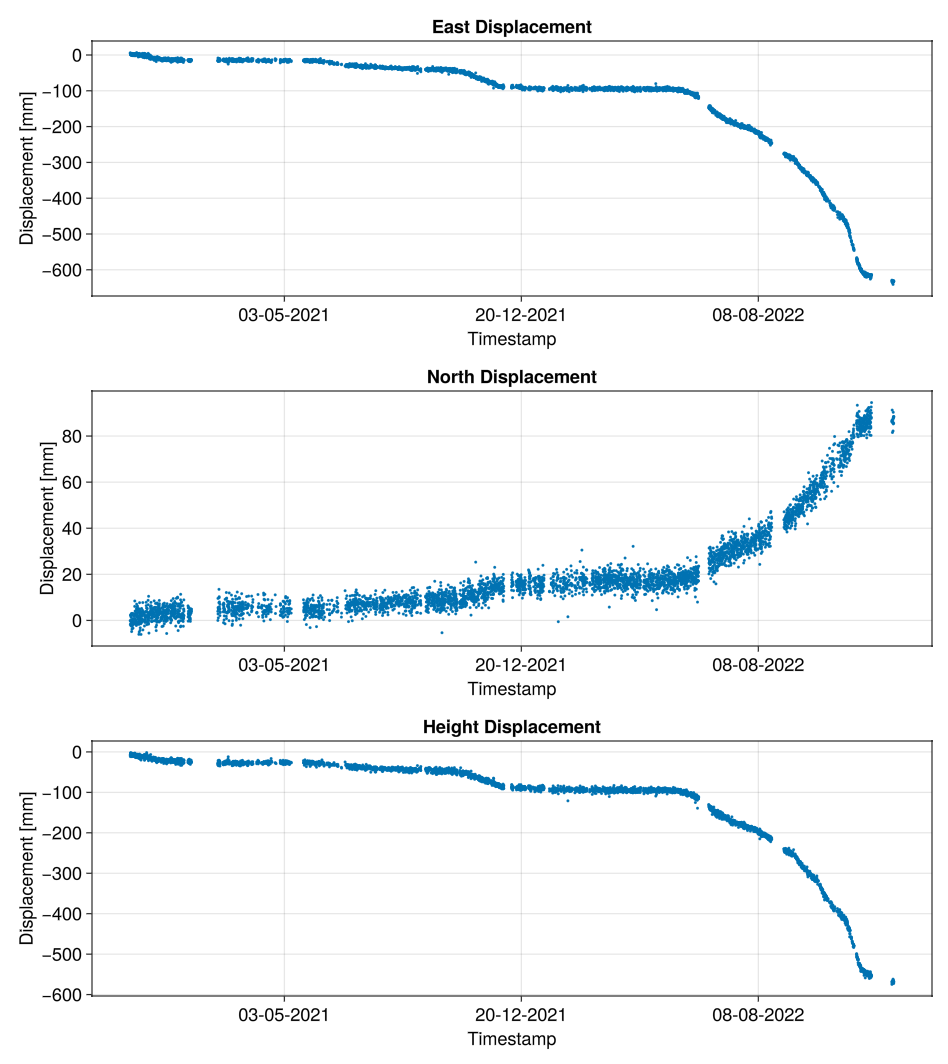

In [138]:
# Visualise Roto-Translation based on Total Station Data
using GLMakie
using ColorTypes
using LinearAlgebra

GLMakie.activate!()
# Plot results
Makie.inline!(true)
fig_res = Figure(; size=(720,1.5*720), title="Roto-Translation based on Total Station Data", fontsize = 18)

x_label = "Timestamp"
y_label = "Displacement [mm]"
x =  datetime2unix.(cumulated_diffs_ts_df.Date)

ax = Axis(fig_res[1, 1], title="East Displacement", ylabel=y_label, xlabel=x_label)
scatter!(ax, x, cumulated_diffs_ts_df.East, markersize=4)

ax2 = Axis(fig_res[2, 1], title="North Displacement", ylabel=y_label, xlabel=x_label)
scatter!(ax2, x, cumulated_diffs_ts_df.North, markersize=4)

ax3 = Axis(fig_res[3, 1], title="Height Displacement",  ylabel=y_label, xlabel=x_label)
scatter!(ax3, x, cumulated_diffs_ts_df.Height, markersize=4)

ax.xtickformat = x -> Dates.format.(unix2datetime.(x), "dd-mm-yyyy")
ax2.xtickformat = x -> Dates.format.(unix2datetime.(x), "dd-mm-yyyy")
ax3.xtickformat = x -> Dates.format.(unix2datetime.(x), "dd-mm-yyyy")

fig_res

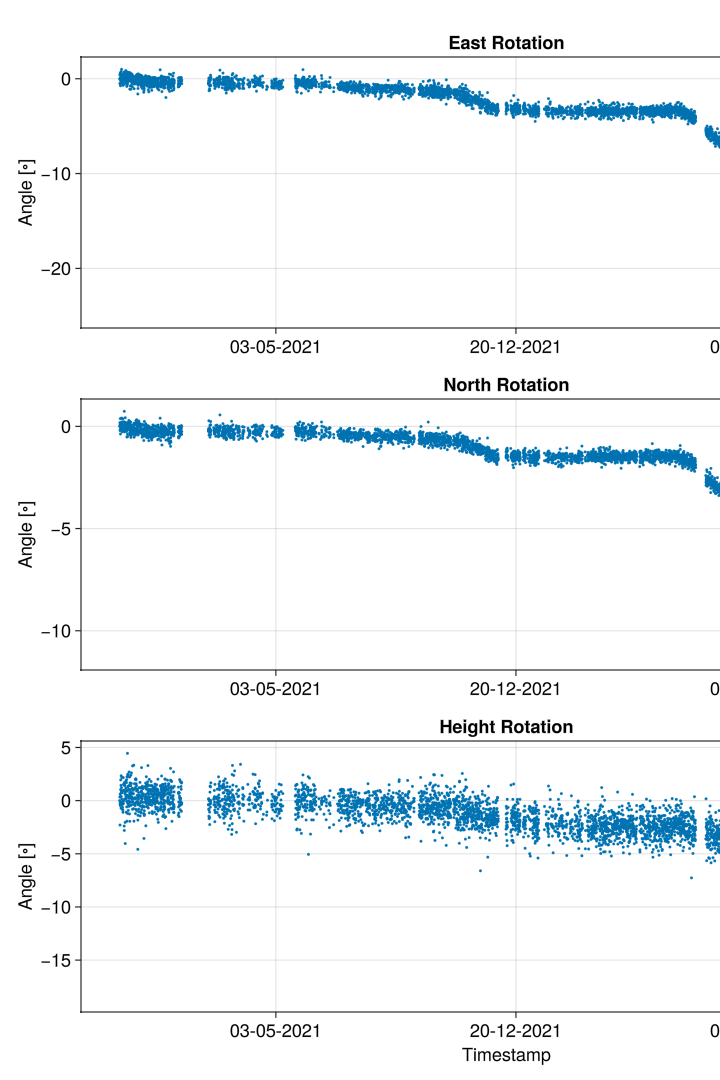

In [139]:
# Plot angles
Makie.inline!(true)
fig_res = Figure(; size=(720,1.5*720), title="Roto-Translation based on Total Station Data", fontsize = 18)

x =  datetime2unix.(cumulated_diffs_ts_df.Date)

ax = Axis(fig_res[1, 1], title="East Rotation", ylabel="Angle [◦]")
scatter!(ax, x, rad2deg.(cumulated_diffs_ts_df.psi), markersize=4)

ax2 = Axis(fig_res[2, 1], title="North Rotation", ylabel="Angle [◦]")
scatter!(ax2, x, rad2deg.(cumulated_diffs_ts_df.theta), markersize=4)

ax3 = Axis(fig_res[3, 1], title="Height Rotation", xlabel="Timestamp", ylabel="Angle [◦]")
scatter!(ax3, x, rad2deg.(cumulated_diffs_ts_df.phi), markersize=4)

ax.xtickformat = x -> Dates.format.(unix2datetime.(x), "dd-mm-yyyy")
ax2.xtickformat = x -> Dates.format.(unix2datetime.(x), "dd-mm-yyyy")
ax3.xtickformat = x -> Dates.format.(unix2datetime.(x), "dd-mm-yyyy")

fig_res

In [140]:
Makie.inline!(true);
include("totalstation_utils.jl")
plot_rototranslation(cumulated_diffs_ts_df)

Compute the variance over the first 100 measurements where we expect no movement (or below detection threshold). The variance will then be used in the measurement covariance matrix of the Kalman Filter.

In [141]:
# Compute variance over first 100 measurements
println("East: ", var(cumulated_diffs_ts_df[1:100, :East]))
println("North: ", var(cumulated_diffs_ts_df[1:100, :North]))
println("Height: ", var(cumulated_diffs_ts_df[1:100, :Height]))

East: 4.7383817880584616
North: 7.921429910302349
Height: 11.025753059957623


### 1.2 Ground Based InSAR

The ground-based InSAR provides data from a nearly North-aligned view angle. Hence, the movement measured by the radar is in Line of Sight, towards the instrument, combining North and Height movement. Based on the initial position of the Block as derived by the initial Total Station Position Measurements from 1.1 and coordinates of the position of the instrument, the view angle is computed. The angle is then used to decompose the measurements into their North and Height components.

Since the measurements of the total station have a large noise components, we use the average over 200 measurements from the beginning of the time series as the initial position of the block. Since no movement has been recorded in this date range, it safe to assume that the block physically maintained the same position over the 200 measurements.

In [142]:
# Fetch data for same date range
println("First date: ", positions[1, "Date"], ": ", mean(positions[1:200, "East"]), ", ", mean(positions[1:200, "North"]), ", ", mean(positions[1:200, "Height"]))
println("Last date: ", positions[end, "Date"])

First date: 2020-12-02T14:00:00: 3.9948494370118904e8, 6.74825305477845e9, 835653.6296973549
Last date: 2022-12-19T08:00:00


Compute view angle to compute displacement towards north and in height based on instrument and object position.

In [143]:
gb_insar_position = (399333, 6750226, 28.350)
block_pos = (399483.298761, 6748250.569140, 835.306976) # from NVE data

# Compute euclidian distance in 2D
function euclidian_distance_2d(x1, y1, x2, y2)
    return sqrt((x1 - x2)^2 + (y1 - y2)^2)
end

distance_2d = euclidian_distance_2d(gb_insar_position[1], gb_insar_position[2], block_pos[1], block_pos[2])
height_diff = block_pos[3] - gb_insar_position[3]

println("Height difference: ", height_diff, " | 2D difference ", distance_2d)

# Compute view angle using 2D distance and height difference
view_angle = atan(height_diff / distance_2d)

println("View angle from atan: ", rad2deg(view_angle))

Height difference: 806.9569759999999 | 2D difference 1981.1402777686915
View angle from atan: 22.16202369189842


Given the view angle $\theta$ of the instrument, we can decompose the LOS measurements into North and Height components using the following equations:

$d_{north} = cos(\theta) * d_{LOS}$

$d_{height} = sin(\theta) * d_{LOS}$


In [144]:
# Load GB-InSAR data froma CSV file
FILE_PATH = "data/stampa_gbinsar.csv";

gb_insar_df = CSV.read(FILE_PATH, DataFrame; delim=';') 

# Parse Dates to timestamps
df_date = []

for i in 1:size(gb_insar_df.TIME, 1)
    push!(df_date, "$(gb_insar_df.Date[i]) $(gb_insar_df.TIME[i])")
end

date_format = DateFormat("dd-mm-yyyy HH:MM:SS");
gb_insar_df.Date = DateTime.(df_date, date_format);

In [145]:
# Select date range of total station
gb_insar_df_filtered = gb_insar_df[(gb_insar_df.Date .> positions[1, "Date"]) .& (gb_insar_df.Date .< positions[end, "Date"]), :];

gb_df = DataFrame()
gb_df[!, "Date"] = gb_insar_df_filtered[1:end,"Date"]
gb_df[:,"Pts_11"] = gb_insar_df_filtered[:,"Pts_11"] .- gb_insar_df_filtered[1,"Pts_11"]
gb_df[:,"Pts_03"] = gb_insar_df_filtered[:,"Pts_03"] .- gb_insar_df_filtered[1,"Pts_03"]
gb_df[end,:]

Row,Date,Pts_11,Pts_03
,DateTime,Float64,Float64
2230,2022-12-19T03:49:00,-321.69,-484.0


In [146]:
gb_df[:,"North"] = gb_df[:, "Pts_11"] .* sin(view_angle - deg2rad(180))
gb_df[:,"Height"] = -gb_df[:, "Pts_11"] .* cos(view_angle - deg2rad(180))

gb_df[:,"BaseNorth"] = gb_df[:, "Pts_03"] .* sin(view_angle - deg2rad(180))
gb_df[:,"BaseHeight"] = -gb_df[:, "Pts_03"] .* cos(view_angle - deg2rad(180))

println("Height and North differences GB-InSAR from \t", gb_df[1, "Date"], " to ", gb_df[end, "Date"], ": ", gb_df[end, "Height"], ", " , gb_df[end, "North"])
println("Height and North differences Total Station from ", cumulated_diffs_ts_df[1, "Date"], " to ", cumulated_diffs_ts_df[end, "Date"], ": ", cumulated_diffs_ts_df[end, "Height"], ", " , cumulated_diffs_ts_df[end, "North"]);

Height and North differences GB-InSAR from 	2020-12-02T19:59:00 to 2022-12-19T03:49:00: -297.9238061602297, 121.35016202297341
Height and North differences Total Station from 2020-12-03T10:00:00 to 2022-12-19T08:00:00: -569.0482281863224, 88.48998260498047


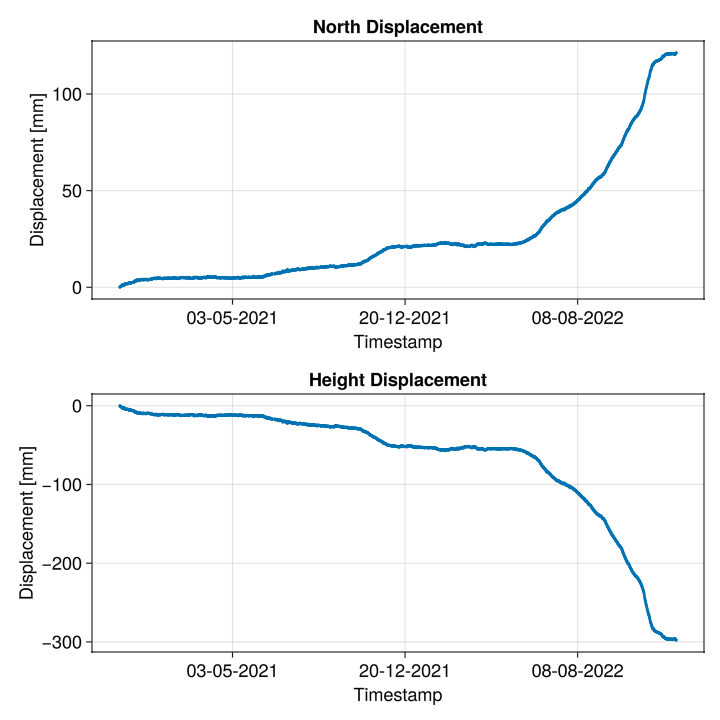

In [147]:
# Plot only gb insar
Makie.inline!(true)
fig_res = Figure(; size=(720,720), fontsize=18)

x_label = "Timestamp"
y_label = "Displacement [mm]"

x1 =  datetime2unix.(gb_df.Date)

ax = Axis(fig_res[1, 1], title="North Displacement", xlabel=x_label, ylabel=y_label)
scatter!(ax, x1, gb_df[:, "North"], markersize=4)

ax2 = Axis(fig_res[2, 1], title="Height Displacement", xlabel=x_label, ylabel=y_label)
scatter!(ax2, x1, gb_df[:, "Height"], markersize=4)

ax.xtickformat = x -> Dates.format.(unix2datetime.(x), "dd-mm-yyyy")
ax2.xtickformat = x -> Dates.format.(unix2datetime.(x), "dd-mm-yyyy")

fig_res

### 1.3 Satellite Based InSAR

In [148]:
# Corner reflector initial position
corner_reflector = (399490.754, 6748254.052, 847.00)

incidence_asc = deg2rad(39.48)
incidence_desc = deg2rad(43.81)

heading_asc = deg2rad(349.36)
heading_desc = deg2rad(184.38)

ew_cos_asc = -cos(heading_asc) * sin(incidence_asc)
ew_cos_desc = -cos(heading_desc) * sin(incidence_desc)
vert_cos_asc = cos(incidence_asc)
vert_cos_desc = cos(incidence_desc)

println(ew_cos_asc, ", ", ew_cos_desc, ", ", vert_cos_asc, ", ", vert_cos_desc)

-0.624877173679023, 0.6902473424983366, 0.771846569558035, 0.7216394153331461


In [149]:
# Load data from csv
descending_df = CSV.read("data/stampa_sat_descending.csv", DataFrame; delim=',')
date_format = DateFormat("yyyy-mm-dd HH:MM:SS");
descending_df.timestamp = DateTime.(descending_df.timestamp, date_format)

# Split into separate dataframes
desc_iw3 = dropmissing(descending_df[:, ["timestamp", "037-0712-iw3"]]);
desc_iw2 = dropmissing(descending_df[:, ["timestamp", "110-0711-iw2"]]);


In [150]:
ascending_df = CSV.read("data/stampa_sat_ascending.csv", DataFrame; delim=',')

ascending_df.timestamp = DateTime.(ascending_df.timestamp, date_format)

# Split into separate dataframes
asc_iw3 = dropmissing(ascending_df[:, ["timestamp", "015-0359-iw3"]]);
asc_iw2 = dropmissing(ascending_df[:, ["timestamp", "117-0361-iw2"]]);

In [151]:
iw2 = dropmissing(outerjoin(desc_iw2, asc_iw2, on=:timestamp));

desc_iw3.timestamp = desc_iw3.timestamp .- Dates.Day(1)
asc_iw3.timestamp = asc_iw3.timestamp .+ Dates.Day(1)

iw3 = dropmissing(outerjoin(desc_iw3, asc_iw3, on=:timestamp));

# Rename columns
rename!(iw2, Symbol("110-0711-iw2") => :desc)
rename!(iw2, Symbol("117-0361-iw2") => :asc)

rename!(iw3, Symbol("037-0712-iw3") => :desc)
rename!(iw3, Symbol("015-0359-iw3") => :asc);

Since the N-S component of the movement is relatively small compared to E-W and height displacements, we can decompose the LOS displacement into E-W and height.

<br>

![image.png](img/sat_decomp.png)

<br>


Given the incidence angle $\theta$ and the heading angle $\alpha$, we can compute a decomposition for every timestep $k$ as follows:

$V_{height,k} = \frac{-cos(\alpha_{k, desc})sin(\theta_{k, desc}) V_{LOS,k, asc} + cos(\alpha_{k, asc})sin(\theta_{k, asc}) V_{LOS, k,desc}}{-cos(\alpha_{k, desc})sin(\theta_{k, desc})cos(\theta_{k, asc}) + cos(\alpha_{k, asc})sin(\theta_{k, ac})cos(\theta_{k, desc})}$

$V_{east, k} = \frac{cos(\theta_{k, asc})V_{LOS,k,desc} - cos(\theta_{k, desc}) V_{LOS, k, asc}}{-cos(\alpha_{k, desc})sin(\theta_{k, desc})cos(\theta_{k, asc}) + cos(\alpha_{k, asc})sin(\theta_{k, ac})cos(\theta_{k, desc})}$

In [152]:
"""
    decompose_sat_los()

Decompose the LOS vector into a East-West and vertical component

"""
function decompose_sat_los(d_los_asc, d_los_desc)

    # Compute the East-West component of the LOS vector
    d_ew = (vert_cos_asc * d_los_desc - vert_cos_desc * d_los_asc) / (ew_cos_desc * vert_cos_asc - ew_cos_asc * vert_cos_desc)

    # Compute the vertical component of the LOS vector
    d_vert = (ew_cos_desc * d_los_asc - ew_cos_asc * d_los_desc) / (ew_cos_desc * vert_cos_asc - ew_cos_asc * vert_cos_desc)

    return d_ew, d_vert
    
end

decompose_sat_los

In [153]:
iw2_d_ew = zeros(size(iw2, 1))
iw2_d_vert = zeros(size(iw2, 1))

for i in 1:size(iw2, 1)
    iw2_d_ew[i], iw2_d_vert[i] = decompose_sat_los(iw2[i, :asc], iw2[i, :desc])
end

iw2[:, :d_ew] = iw2_d_ew
iw2[:, :d_vert] = iw2_d_vert

iw3_d_ew = zeros(size(iw3, 1))
iw3_d_vert = zeros(size(iw3, 1))

for i in 1:size(iw3, 1)
    iw3_d_ew[i], iw3_d_vert[i] = decompose_sat_los(iw3[i, :asc], iw3[i, :desc])
end

iw3[:, :d_ew] = iw3_d_ew;
iw3[:, :d_vert] = iw3_d_vert;

In [154]:
# Filter time series by date and align new start to zero
iw2 = iw2[(iw2.timestamp .> positions[1, "Date"]) .& (iw2.timestamp .< positions[end, "Date"]), :]
iw2.d_ew .-= iw2.d_ew[1];
iw2.d_vert .-= iw2.d_vert[1];

In [155]:
# Filter time series by date and align new start to zero
iw3 = iw3[(iw3.timestamp .> positions[1, "Date"]) .& (iw3.timestamp .< positions[end, "Date"]), :]
iw3.d_ew .-= iw3.d_ew[1];
iw3.d_vert .-= iw3.d_vert[1];

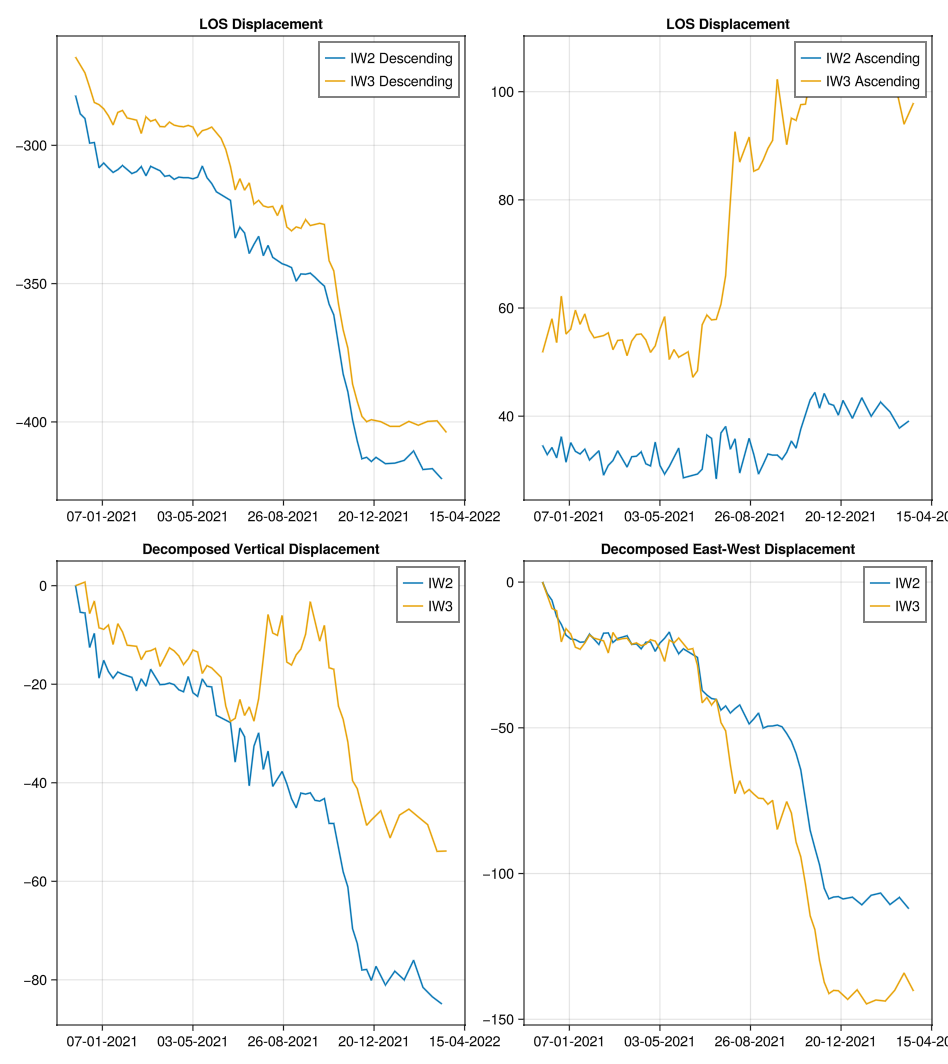

In [156]:
# Plot results
Makie.inline!(true)
fig_res = Figure(; size=(1.5*720,720))

x1 =  datetime2unix.(iw2.timestamp)
x2 =  datetime2unix.(iw3.timestamp)

ax = Axis(fig_res[1, 1], title="LOS Displacement")
lines!(ax, x1, iw2[:, :desc], label="IW2 Descending")
lines!(ax, x2, iw3[:, :desc], label="IW3 Descending")

ax2 = Axis(fig_res[1, 2], title="LOS Displacement")
lines!(ax2, x1, iw2[:, :asc], label="IW2 Ascending")
lines!(ax2, x2, iw3[:, :asc], label="IW3 Ascending")

ax3 = Axis(fig_res[2, 1], title="Decomposed Vertical Displacement")
lines!(ax3, x1, iw2[:, :d_vert], label="IW2")
lines!(ax3, x2, iw3[:, :d_vert], label="IW3")

ax4 = Axis(fig_res[2, 2], title="Decomposed East-West Displacement")
lines!(ax4, x1, iw2[:, :d_ew], label="IW2")
lines!(ax4, x2, iw3[:, :d_ew], label="IW3")

ax.xtickformat = x -> Dates.format.(unix2datetime.(x), "dd-mm-yyyy")
ax2.xtickformat = x -> Dates.format.(unix2datetime.(x), "dd-mm-yyyy")
ax3.xtickformat = x -> Dates.format.(unix2datetime.(x), "dd-mm-yyyy")
ax4.xtickformat = x -> Dates.format.(unix2datetime.(x), "dd-mm-yyyy")

axislegend(ax, merge = true)
axislegend(ax2, merge = true)
axislegend(ax3, merge = true)
axislegend(ax4, merge = true)

fig_res

This gives two series of satellite measurements for the corner reflector on the block. When combined, we can get more accurate data than what the single time series can provide (also the measurement method has large errors that come with it especially when the displacement rates are high).


In [157]:
# Combine the two time series with an average
satellite_insar = DataFrame()

dates = []
ew = []
up = []

for i in 1:length(iw3.timestamp)

    d_ew = iw3.d_ew[i]
    d_vert = iw3.d_vert[i]

    if iw3.timestamp[i] in iw2.timestamp
        findfirst(date -> date == iw3.timestamp[i] , iw2.timestamp)
        
        d_ew +=  iw2.d_ew[i]
        d_ew /= 2
    
        d_vert +=  iw2.d_vert[i]
        d_vert /= 2
    end

    push!(dates, iw3.timestamp[i])
    push!(ew, d_ew)
    push!(up, d_vert)
end


sat_d_ew = similar(ew, Float64)
sat_d_ew .= ew

sat_d_vert = similar(up, Float64)
sat_d_vert .= up

68-element Vector{Float64}:
   0.0
  -2.3278801184296896
  -5.60703658289394
  -7.830056545635941
  -9.108236073406133
 -13.80815889055529
 -11.571272780783445
 -14.664647783008945
 -13.25238431813493
 -13.449206425446107
   ⋮
 -64.30191566067748
 -45.69213980781578
 -51.19264171184798
 -46.561526904333675
 -45.347943105762596
 -46.93895025048232
 -48.505521383613285
 -53.92177931668485
 -53.85318072480629

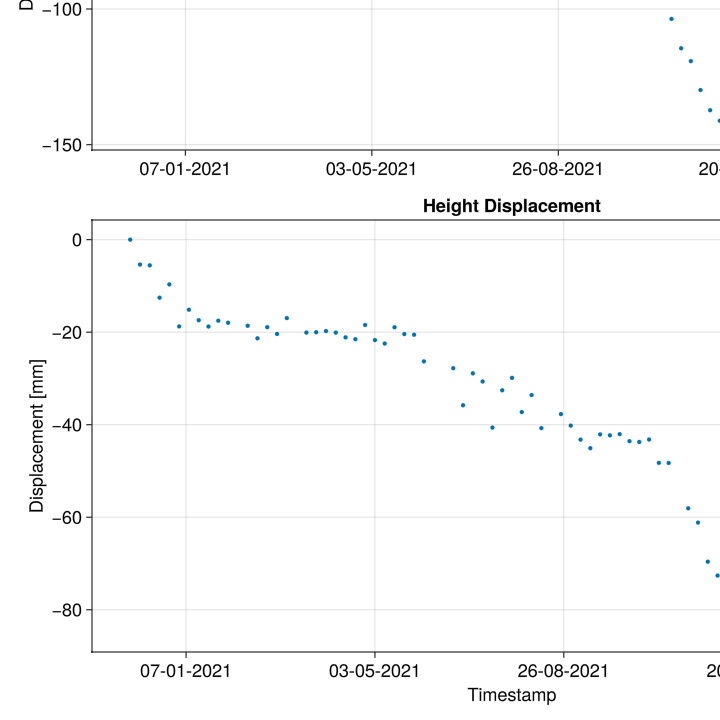

In [158]:
# Plot results
Makie.inline!(true)
fig_res = Figure(; size=(720,720), title="Displacement Decomposition Sat InSAR", fontsize=18)

x2 =  datetime2unix.(iw2.timestamp)
x3 = datetime2unix.(iw3.timestamp)

ax = Axis(fig_res[1, 1], title="East Displacement", ylabel="Displacement [mm]")
scatter!(ax, x3, iw3.d_ew, markersize=6)

ax2 = Axis(fig_res[2, 1], title="Height Displacement", xlabel="Timestamp", ylabel="Displacement [mm]")
scatter!(ax2, x2, iw2.d_vert, markersize=6)

xspace = maximum(tight_xticklabel_spacing!, [ax2, ax3])
ax2.xticklabelspace = xspace

ax.xtickformat = x -> Dates.format.(unix2datetime.(x), "dd-mm-yyyy")
ax2.xtickformat = x -> Dates.format.(unix2datetime.(x), "dd-mm-yyyy")

fig_res

In [159]:
println("Var of decomposed East-West component iw2: ", var(iw2[1:6, :d_ew]))
println("Var of decomposed Vertical component iw2: ", var(iw2[1:6, :d_vert]))
println("Var of decomposed East-West component iw3: ", var(iw3[1:6, :d_ew]))
println("Var of decomposed Vertical component iw3: ", var(iw3[1:6, :d_vert]))

Var of decomposed East-West component iw2: 47.47041164230849
Var of decomposed Vertical component iw2: 42.67218310525548
Var of decomposed East-West component iw3: 55.84769009692733
Var of decomposed Vertical component iw3: 17.159756139938263


### 1.4 Extensometer Data

Pre-processing (filtering) and decomposition of extensometer data. Basic filtering and decompoistion is implemented in [extensometer_pre.jl](extensometer_pre.jl)


```jl
df.Vertical = df[:, col_name_los] .* sin.(view_angle * pi / 180)
df.Easting = df[:, col_name_los] .* cos.(view_angle * pi / 180)
```

In [160]:
include("extensometer_pre.jl")

extensometer_df = get_level_zero_extensometer("data/stampa_extensometer.csv", positions[1, "Date"], positions[end, "Date"]);

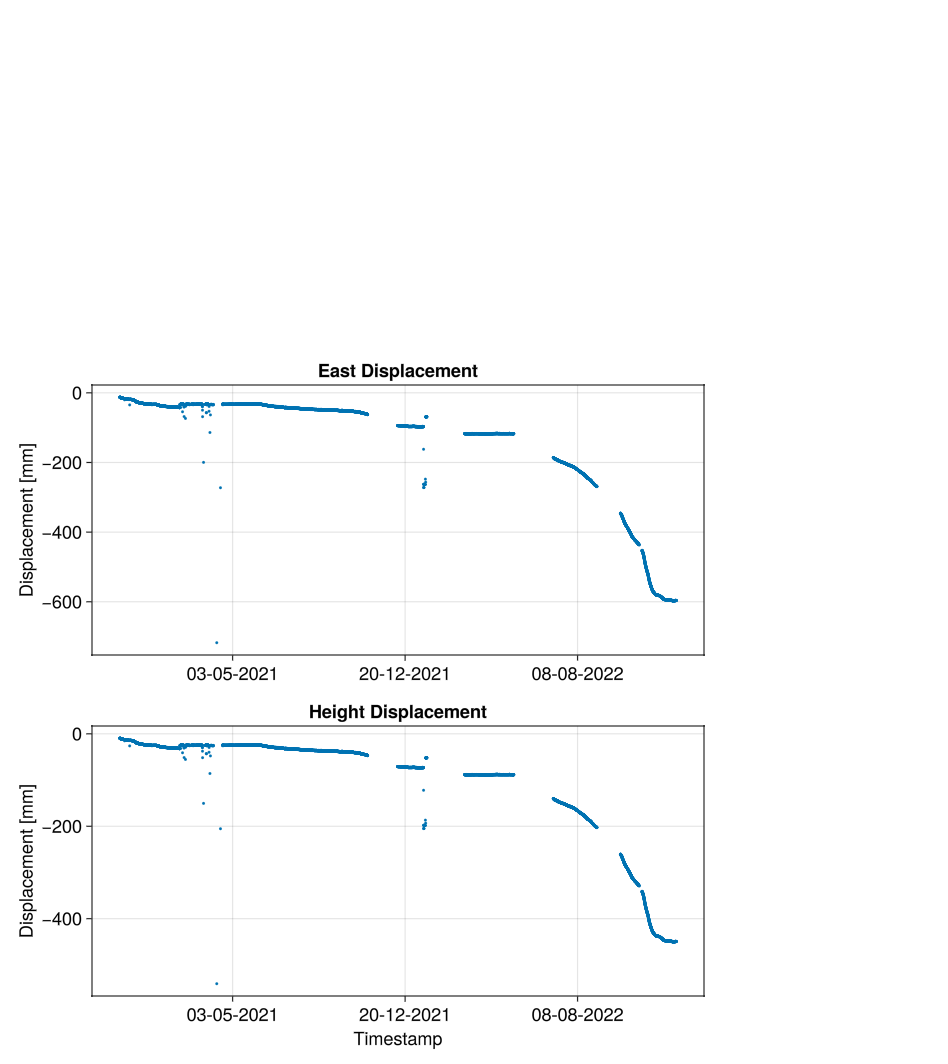

In [161]:
Makie.inline!(true)
fig_ext = Figure(; size=(720,720), fontsize=18)

x = datetime2unix.(extensometer_df.Date)

ax = Axis(fig_ext[1, 1], title="East Displacement", ylabel="Displacement [mm]")
scatter!(ax, x, -extensometer_df.Easting, markersize=4)

ax2 = Axis(fig_ext[2, 1], title="Height Displacement", xlabel="Timestamp", ylabel="Displacement [mm]")
scatter!(ax2, x, -extensometer_df.Vertical, markersize=4)

ax.xtickformat = x -> Dates.format.(unix2datetime.(x), "dd-mm-yyyy")
ax2.xtickformat = x -> Dates.format.(unix2datetime.(x), "dd-mm-yyyy")

fig_ext

### 1.5 Tiltmeter Data

Tiltmeter data provides rotation around two axis

In [162]:
# Load tiltmeter data
df_tilt = CSV.read("data/stampa_tiltmeter.csv", DataFrame)

function parse_date(date_str::AbstractString)
    return DateTime(date_str, "dd.mm.yyyy HH:MM:SS")
end

df_tilt.Date = map(parse_date, df_tilt.Date);

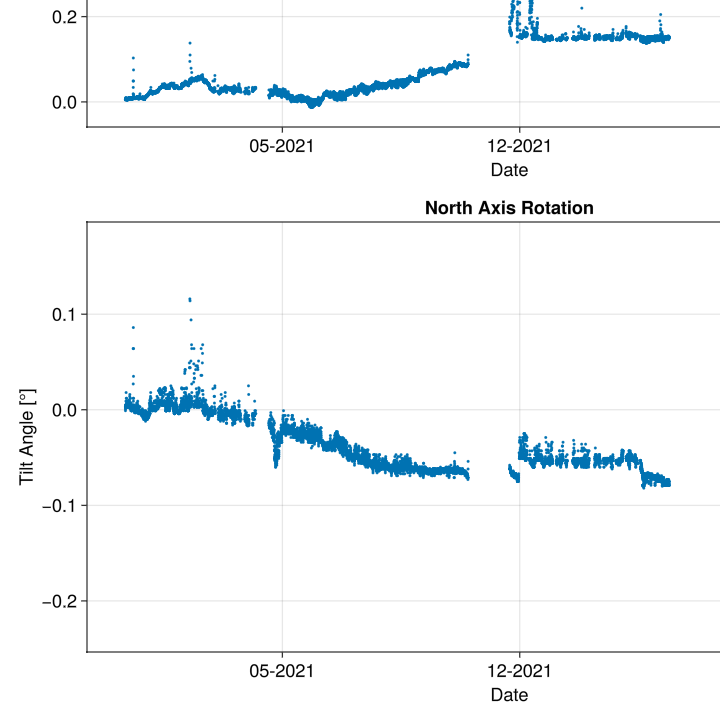

In [163]:
Makie.inline!(true);

# Plot single components with autoscale
fig = Figure(; size=(720,720), fontsize=18)

ax = Axis(fig[2, 1], title="North Axis Rotation", xlabel="Date", ylabel="Tilt Angle [°]")
x = datetime2unix.(df_tilt.Date)
y = df_tilt.dX.+1
scatter!(ax, x, y, label="Axis A Tilt", markersize=4)

ax2 = Axis(fig[1, 1], title="East Axis Rotation", xlabel="Date", ylabel="Tilt Angle [°]")
y2 = df_tilt.dY
scatter!(ax2, x, y2, label="Axis A Tilt", markersize=4)

ax.xtickformat = ax2.xtickformat = x -> Dates.format.(unix2datetime.(x), "mm-yyyy")

fig

## 2. Prepare Measurements for Data Fusion

All measurements will be used in chronological order. For this, we create one matrix to hold all measurements, annotated with sensor information to choose the correct measurement matrix and measurement covariance matrix when updating the Kalman Filter state.

The following format is being used in the matrix:

| Timestamp | Sensor Name | Description | Measurement Values |

The length of the measurement values (Array{Float64}) varies according to the sensor, hence the choice of the correct measurement matrix is crucial to map measurements to system states.

In [164]:
# Put all measurements into one list with their respective timestamps ordered by timestamp
iw2_range = iw2[iw2.timestamp .> positions[1, "Date"], :]
iw3_range = iw3[iw3.timestamp .> positions[1, "Date"], :]
iw2_range.d_ew = iw2_range.d_ew .- iw2_range.d_ew[1]
iw2_range.d_vert = iw2_range.d_vert .- iw2_range.d_vert[1]
iw3_range.d_ew = iw3_range.d_ew .- iw3_range.d_ew[1]
iw3_range.d_vert = iw3_range.d_vert .- iw3_range.d_vert[1];

In [165]:
measurements_sat = [iw2_range.timestamp; iw3_range.timestamp]
measurements_sat = [measurements_sat zeros(length(measurements_sat)) zeros(length(measurements_sat)) zeros(length(measurements_sat))]

# Fill 2nd and 3rd column with senor type and measurements
for i in 1:length(iw2_range.timestamp)

    measurements_sat[i,2] = "SAT-INSAR"
    measurements_sat[i,3] = "IW2"
    measurements_sat[i,4] = [iw2_range.d_ew[i] iw2_range.d_vert[i]]
    
end

for i in length(iw2_range.timestamp)+1:size(measurements_sat,1)

    measurements_sat[i,2] = "SAT-INSAR"
    measurements_sat[i,3] = "IW3"
    measurements_sat[i,4] = [iw3_range.d_ew[i-length(iw2_range.timestamp)] iw3_range.d_vert[i-length(iw2_range.timestamp)]]

end


In [166]:
# Create measurements vector for gb-insar DataFrame
measurements_gb = gb_df.Date
measurements_gb = [measurements_gb zeros(length(measurements_gb)) zeros(length(measurements_gb)) zeros(length(measurements_gb))]

gb_d_ns = gb_df[:, "North"]
gb_d_vert = gb_df[:, "Height"]

# Fill 2nd, 3rd and 4th column with senor type, description and measurements
for i in 1:size(measurements_gb, 1)

    measurements_gb[i,2] = "GB-INSAR"
    measurements_gb[i,3] = "Pts_11"
    measurements_gb[i,4] = [gb_d_ns[i] gb_d_vert[i]]
    
end

onesy = measurements_gb[1,:];

In [167]:
# Adapt extensometer measurements to the same time scale as the other sensors
ext_range = extensometer_df[extensometer_df.Date .> positions[1, "Date"], :]
ext_range = ext_range[ext_range.Date .< positions[end, "Date"], :]
ext_range.Easting = -(ext_range.Easting .- ext_range.Easting[1]);
ext_range.Vertical = -(ext_range.Vertical .- ext_range.Vertical[1]);

# Create measurements vector for total station data
measurements_ext = ext_range.Date

measurements_ext = [measurements_ext zeros(length(measurements_ext)) zeros(length(measurements_ext)) zeros(length(measurements_ext))]

# Fill 2nd, 3rd and 4th column with senor type, description and measurements
for i in 1:size(measurements_ext, 1)

    measurements_ext[i,2] = "Extensometer"
    measurements_ext[i,3] = "Block4a"
    measurements_ext[i,4] = [ext_range.Easting[i] ext_range.Vertical[i]]
    
end

In [168]:
# Create measurements vector for total station data
measurements_ts = cumulated_diffs_ts_df.Date

measurements_ts = [measurements_ts zeros(length(measurements_ts)) zeros(length(measurements_ts)) zeros(length(measurements_ts))]

# Fill 2nd, 3rd and 4th column with senor type, description and measurements
for i in 1:size(measurements_ts, 1)

    measurements_ts[i,2] = "Total Station"
    measurements_ts[i,3] = "Combined"
    measurements_ts[i,4] = [cumulated_diffs_ts_df.East[i] cumulated_diffs_ts_df.North[i] cumulated_diffs_ts_df.Height[i]]
    
end

In [169]:
# Combine sensor measurements
measurements = [measurements_sat; measurements_gb; measurements_ts; measurements_ext]

# Sort by timestamp
measurements = measurements[sortperm(measurements[:,1]), :];

size(measurements)

(19615, 4)

## 3. Data Fusion for Block4a (Upper Part) with MAKF

### 3.1 Local Filter Total Station

In [170]:
# Filter for Total Station
include("asynchronous_kalman_filter.jl")

x0 = [0.; 0.; 0.]
P0 = diagm([1.,1.,1.])
A = diagm([1., 1., 1.])
Q = diagm([1., 1., 1.])
H = [1. 0 0; 0 1. 0; 0 0 1.]
R = [10. 0 0; 0 10. 0; 0 0 10.]

tracking = Tracking(
    x0,         # state vector
    P0,         # state covariance matrix
    A,          # state transition matrix
    Q,          # process covariance matrix
    H,          # Measurement matrix satellite
    R,          # Measurement covariance satellite
    zeros(3, 3) # Kalman filter gain
)

x_est = [[0., 0., 0.]]    # State vector
timestamps_ts = []
sensors = ["Total Station"]

for i in 1:size(measurements,1)

    # Use function updating velocity
    timestamp = process_measurement(tracking, measurements[i,:], sensors)

    if (timestamp != nothing)
        push!(timestamps_ts, timestamp)
        push!(x_est, tracking.kf.x)
    end

end

# Decompose state vector into seperate vectors
local_ts_east = [x_est[i][1] for i in 2:length(x_est)];
local_ts_north = [x_est[i][2] for i in 2:length(x_est)];
local_ts_height = [x_est[i][3] for i in 2:length(x_est)];

Kalman Filter Initialization


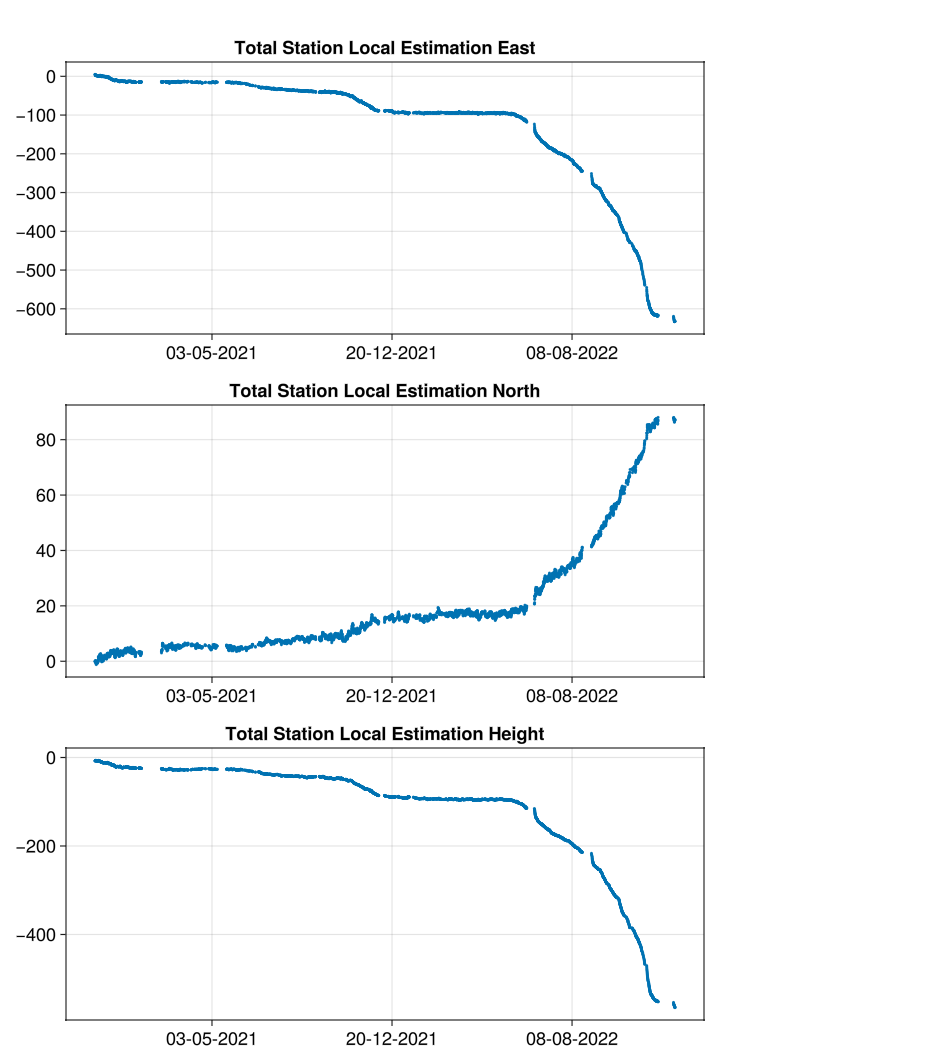

In [171]:
# Plot estimation results
Makie.inline!(true)
fig_res = Figure(; size=(720,1.5*720), fontsize=18)

x =  datetime2unix.(timestamps_ts)

ax = Axis(fig_res[1, 1], title="Total Station Local Estimation East")
scatter!(ax, x, local_ts_east, markersize=4)

ax2 = Axis(fig_res[2, 1], title="Total Station Local Estimation North")
scatter!(ax2, x, local_ts_north, markersize=4)

ax3 = Axis(fig_res[3, 1], title="Total Station Local Estimation Height")
scatter!(ax3, x, local_ts_height, markersize=4)

ax.xtickformat = x -> Dates.format.(unix2datetime.(x), "dd-mm-yyyy")
ax2.xtickformat = x -> Dates.format.(unix2datetime.(x), "dd-mm-yyyy")
ax3.xtickformat = x -> Dates.format.(unix2datetime.(x), "dd-mm-yyyy")

fig_res

In [172]:
# Export Total Station
df = DataFrame(
    timestamp = timestamps_ts,
    easting = local_ts_east,
    northing = local_ts_north,
    height = local_ts_height
)
# Write to CSV file
CSV.write("output/local_block4a_ts.csv", df)

"output/local_block4a_ts.csv"

### 3.2 Local Filter Satellite based InSAR

In [173]:
# Filter for satellite InSAR
include("asynchronous_kalman_filter.jl")

x0 = [0.; 0.; 0.]
P0 = diagm([1.,1.,1.])
A = diagm([1., 1., 1.])
Q = diagm([1., 1., 1.])
H = [1. 0 0; 0 1. 0; 0 0 1.]
R = [10. 0 0; 0 10. 0; 0 0 10.]

tracking = Tracking(
    x0,         # state vector
    P0,         # state covariance matrix
    A,          # state transition matrix
    Q,          # process covariance matrix
    H,          # Measurement matrix satellite
    R,          # Measurement covariance satellite
    zeros(3, 3) # Kalman filter gain
)

x_est = [[0., 0., 0.]]    # State vector
timestamps_sat = []
sensors = ["SAT-INSAR"]

for i in 1:size(measurements,1)

    # Use function updating velocity
    timestamp = process_measurement(tracking, measurements[i,:], sensors)

    if (timestamp != nothing)
        push!(timestamps_sat, timestamp)
        push!(x_est, tracking.kf.x)
    end

end

# Decompose state vector into seperate vectors
local_sat_east = [x_est[i][1] for i in 2:length(x_est)];
local_sat_north = [x_est[i][2] for i in 2:length(x_est)];
local_sat_height = [x_est[i][3] for i in 2:length(x_est)];

Kalman Filter Initialization


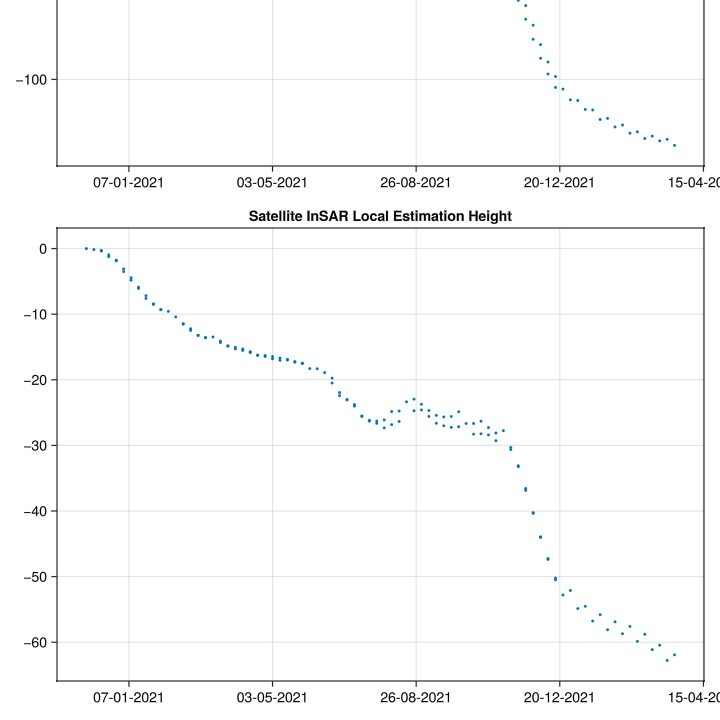

In [174]:
# Plot estimation results
Makie.inline!(true)
fig_res = Figure(; size=(720,720))

x =  datetime2unix.(timestamps_sat)

ax = Axis(fig_res[1, 1], title="Satellite InSAR Local Estimation East")
scatter!(ax, x, local_sat_east, markersize=4)

ax3 = Axis(fig_res[2, 1], title="Satellite InSAR Local Estimation Height")
scatter!(ax3, x, local_sat_height, markersize=4)

ax.xtickformat = x -> Dates.format.(unix2datetime.(x), "dd-mm-yyyy")
ax3.xtickformat = x -> Dates.format.(unix2datetime.(x), "dd-mm-yyyy")

fig_res

In [175]:
# Export satellite InSAR
df = DataFrame(
    timestamp = timestamps_sat,
    easting = local_sat_east,
    height = local_sat_height
)
# Write to CSV file
CSV.write("output/local_block4a_sat.csv", df)

"output/local_block4a_sat.csv"

### 3.3 Local Filter GB-InSAR

In [176]:
# Filter for ground-based InSAR
include("asynchronous_kalman_filter.jl")

x0 = [0.; 0.; 0.]
P0 = diagm([1.,1.,1.])
A = diagm([1., 1., 1.])
Q = diagm([1., 1., 1.])
H = [1. 0 0; 0 1. 0; 0 0 1.]
R = [10. 0 0; 0 10. 0; 0 0 10.]

tracking = Tracking(
    x0,         # state vector
    P0,         # state covariance matrix
    A,          # state transition matrix
    Q,          # process covariance matrix
    H,          # Measurement matrix ground-based InSAR
    R,          # Measurement covariance ground-based InSAR
    zeros(3, 3) # Kalman filter gain
)

x_est = [[0., 0., 0.]]    # State vector
timestamps_gb = []
sensors = ["GB-INSAR"]

for i in 1:size(measurements,1)

    timestamp = process_measurement(tracking, measurements[i,:], sensors)

    if (timestamp != nothing)
        push!(timestamps_gb, timestamp)
        push!(x_est, tracking.kf.x)
    end

end

# Decompose state vector into seperate vectors
local_gb_east = [x_est[i][1] for i in 2:length(x_est)];
local_gb_north = [x_est[i][2] for i in 2:length(x_est)];
local_gb_height = [x_est[i][3] for i in 2:length(x_est)];

Kalman Filter Initialization


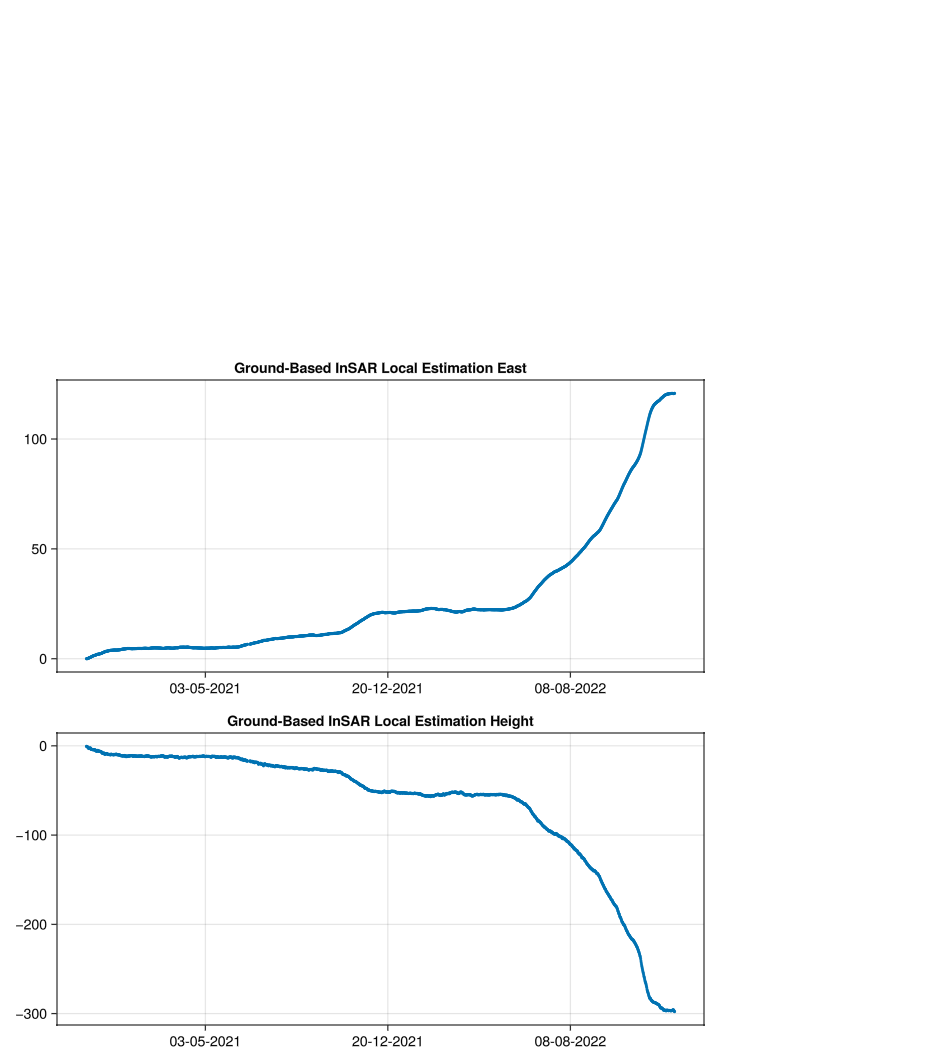

In [177]:
# Plot estimation results
Makie.inline!(true)
fig_res = Figure(; size=(720,720))

x =  datetime2unix.(timestamps_gb)

ax = Axis(fig_res[1, 1], title="Ground-Based InSAR Local Estimation East")
scatter!(ax, x, local_gb_north, markersize=4)

ax3 = Axis(fig_res[2, 1], title="Ground-Based InSAR Local Estimation Height")
scatter!(ax3, x, local_gb_height, markersize=4)

ax.xtickformat = x -> Dates.format.(unix2datetime.(x), "dd-mm-yyyy")
ax3.xtickformat = x -> Dates.format.(unix2datetime.(x), "dd-mm-yyyy")

fig_res

In [178]:
# Export ground-based InSAR
df = DataFrame(
    timestamp = timestamps_gb,
    northing = local_gb_north,
    height = local_gb_height
)
# Write to CSV file
CSV.write("output/local_block4a_gb.csv", df)

"output/local_block4a_gb.csv"

### 3.4 Local Filter Extensometer

In [179]:
# Filter for extensometer
include("asynchronous_kalman_filter.jl")

x0 = [0.; 0.; 0.]
P0 = diagm([1.,1.,1.])
A = diagm([1., 1., 1.])
Q = diagm([1., 1., 1.])
H = [1. 0 0; 0 1. 0; 0 0 1.]
R = [10. 0 0; 0 10. 0; 0 0 10.]

tracking = Tracking(
    x0,         # state vector
    P0,         # state covariance matrix
    A,          # state transition matrix
    Q,          # process covariance matrix
    H,          # Measurement matrix satellite
    R,          # Measurement covariance satellite
    zeros(3, 3) # Kalman filter gain
)

x_est = [[0., 0., 0.]]    # State vector
timestamps_ext = []
sensors = ["Extensometer"]

for i in 1:size(measurements,1)

    # Use function updating velocity
    timestamp = process_measurement(tracking, measurements[i,:], sensors)

    if (timestamp != nothing)
        push!(timestamps_ext, timestamp)
        push!(x_est, tracking.kf.x)
    end

end

# Decompose state vector into seperate vectors
local_ext_east = [x_est[i][1] for i in 2:length(x_est)];
local_ext_north = [x_est[i][2] for i in 2:length(x_est)];
local_ext_height = [x_est[i][3] for i in 2:length(x_est)];

Kalman Filter Initialization


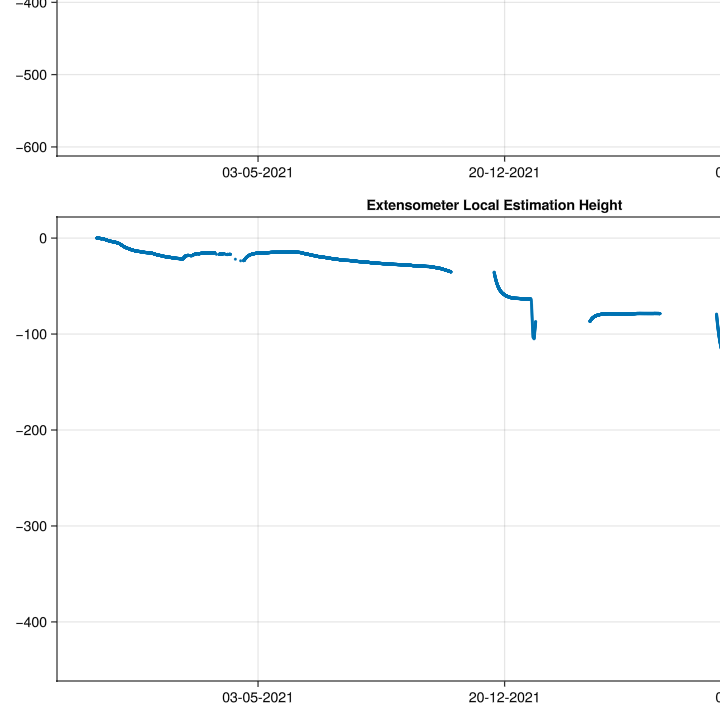

In [180]:
# Plot estimation results
Makie.inline!(true)
fig_res = Figure(; size=(720,720))

x =  datetime2unix.(timestamps_ext)

ax = Axis(fig_res[1, 1], title="Extensometer Local Estimation East")
scatter!(ax, x, local_ext_east, markersize=4)

ax3 = Axis(fig_res[2, 1], title="Extensometer Local Estimation Height")
scatter!(ax3, x, local_ext_height, markersize=4)

ax.xtickformat = x -> Dates.format.(unix2datetime.(x), "dd-mm-yyyy")
ax3.xtickformat = x -> Dates.format.(unix2datetime.(x), "dd-mm-yyyy")

fig_res

In [181]:
# Export extensometer
df = DataFrame(
    timestamp = timestamps_ext,
    easting = local_ext_east,
    height = local_ext_height
)
# Write to CSV file
CSV.write("output/local_block4a_ext.csv", df)

"output/local_block4a_ext.csv"

### 3.5 Resample to create input for Global filter

Due to Julia not having a built-in resampling function, the resampling and filtering is done in a python notebook ([resampling_python.ipynb](resampling_python.ipynb))

Run the cells for the Block4a data in the python notebook and continue below. Intermediate results stored as CSV files are used to pass the data between the two notebooks.

### 3.6 Global Fusion of local estimates

Load the aligned / resampled data for the global filter (synchronous)

In [182]:
function parse_date(date_str::AbstractString)
    return DateTime(date_str, "yyyy-mm-dd HH:MM:SS")
end

parse_date (generic function with 1 method)

In [183]:
# Import data from output folder
df_all = CSV.read("output/local_all_filtered_block4a.csv", DataFrame)

# Convert String timestamps to datetime in timestamp Column
df_all.timestamp = map(parse_date, df_all.timestamp);

Construct filter and compute estimates

In [184]:
# Filter for extensometer
include("asynchronous_kalman_filter.jl")

x0_global = [0.0; 0.0; 0.0]
P0_global = diagm([1.0, 1.0, 1.0])
A_global = diagm([1.0, 1.0, 1.0])
Q_global = diagm([10.0, 10.0, 10.0])

H_global_all = [1.0 0 0 #ts_east
    0 1.0 0     #ts_north
    0 0 1.0     #ts_height 
    0 1.0 0     #gb_north
    0 0 1.0     #gb_height
    1.0 0 0     #ext_east
    0 0 1.0     #ext_height
    1.0 0 0     #sat_east
    0 0 1.0     #sat_height
]
H_global_nosat = [1.0 0 0 #ts_east
    0 1.0 0     #ts_north
    0 0 1.0     #ts_height 
    0 1.0 0     #gb_north
    0 0 1.0     #gb_height
    1.0 0 0     #ext_east
    0 0 1.0     #ext_height
]

R_global_all = diagm([1.0^2, 1.0^2, 1.0^2, 2.0867^2, 4.3622^2, 9.9869^2, 8.3061^2, 12.5^2, 10.0^2])
R_global_nosat = diagm([1.0^2, 1.0^2, 1.0^2, 2.0867^2, 4.3622^2, 9.9869^2, 8.3061^2])

global_est_KF = [[0.0, 0.0, 0.0]]   # State vector
global_K = zeros(3,3)               # Kalman gain

x = x0_global
P = P0_global
K = zeros(3, 3)

for i in 10:size(df_all, 1)

    # Predict
    x = A_global * x
    P = A_global * P * A_global' + Q_global

    # check if satellite data available
    if ismissing(df_all[i, "sat_east"]) || ismissing(df_all[i, "sat_height"])
        H_global = H_global_nosat
        R_global = R_global_nosat
        z = [
            df_all[i, "ts_east"]
            df_all[i, "ts_north"]
            df_all[i, "ts_height"]
            df_all[i, "gb_north"]
            df_all[i, "gb_height"]
            df_all[i, "ext_east"]
            df_all[i, "ext_height"]
        ]
    else
        H_global = H_global_all
        R_global = R_global_all
        z = [
            df_all[i, "ts_east"]
            df_all[i, "ts_north"]
            df_all[i, "ts_height"]
            df_all[i, "gb_north"]
            df_all[i, "gb_height"]
            df_all[i, "ext_east"]
            df_all[i, "ext_height"]
            df_all[i, "sat_east"]
            df_all[i, "sat_height"]
        ]
    end

    # update
    z_pred = H_global * x
    y = z - z_pred
    Ht = H_global'
    S = H_global * P * Ht + R_global
    K = P * Ht * inv(S)
    x = x + K * y
    P = (I - K * H_global) * P

    push!(global_est_KF, x)
    global_K = hcat(global_K, K)

end

# Decompose state vector into seperate vectors
global_east_KF = [global_est_KF[i][1] for i in 2:length(global_est_KF)];
global_north_KF = [global_est_KF[i][2] for i in 2:length(global_est_KF)];
global_height_KF = [global_est_KF[i][3] for i in 2:length(global_est_KF)];

In [185]:
# Compute speeds
gobal_speed_east_KF = [0;diff(global_east_KF[1:end]).*4]
gobal_speed_north_KF = [0;diff(global_north_KF[1:end]).*4]
gobal_speed_height_KF = [0;diff(global_height_KF[1:end]).*4]

# Find values with speeds above 10 mm/h and filter them (set to 0)
gobal_speed_east_KF[gobal_speed_east_KF .> 10] .= 0
gobal_speed_north_KF[gobal_speed_north_KF .> 10] .= 0
gobal_speed_height_KF[abs.(gobal_speed_height_KF) .> 10] .= 0
# gobal_speed_height[gobal_speed_height .< 10] .= 0

0-element view(::Vector{Float64}, Int64[]) with eltype Float64

In [186]:
# Compute 3D displacement
global_displ_KF = [sqrt(global_east_KF[i]^2 + global_north_KF[i]^2 + global_height_KF[i]^2) for i in 1:length(global_east_KF)];

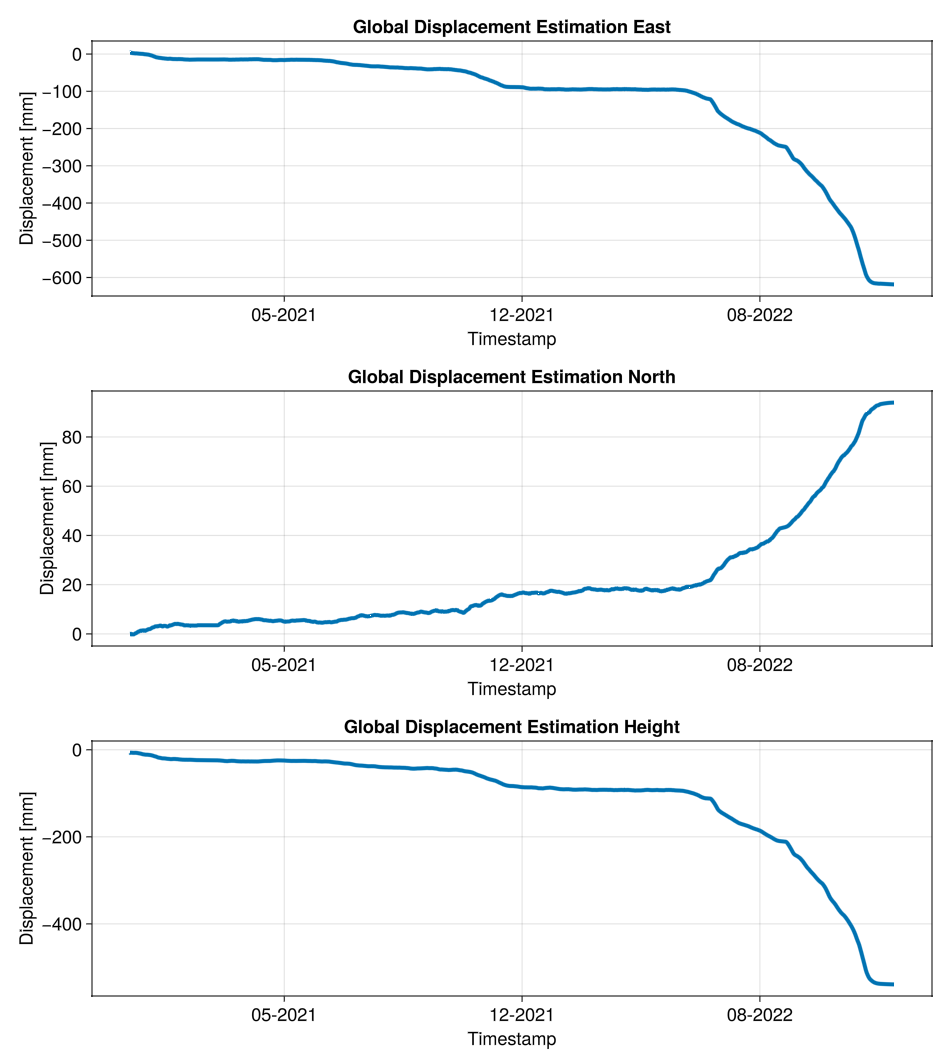

In [187]:
# Plot estimation results displacement
Makie.inline!(true)
fig_res = Figure(; size=(720, 1.5*720), fontsize=18)

offset = 12

x_label = "Timestamp"
y_label = "Displacement [mm]"
x =  datetime2unix.(df_all.timestamp[10:end-offset])

ax = Axis(fig_res[1, 1], title="Global Displacement Estimation East", xlabel=x_label, ylabel=y_label)
# ax_2 = Axis(fig_res[1, 1], ylabel="Velocity [mm/h]", yaxisposition=:right)
# hidexdecorations!(ax_2)
# hidespines!(ax_2)
displ_line = lines!(ax, x, global_east_KF[1:end-offset], linewidth=4, label="Displacement")
# vel_line = lines!(ax_2, x, gobal_speed_east_KF[1:end-offset], linewidth=4, color=:red, label="Velocity")

ax2 = Axis(fig_res[2, 1], title="Global Displacement Estimation North", xlabel=x_label, ylabel=y_label)
# ax2_2 = Axis(fig_res[2, 1], ylabel="Velocity [mm/h]", yaxisposition=:right)
# hidexdecorations!(ax2_2)
# hidespines!(ax2_2)
lines!(ax2, x, global_north_KF[1:end-offset], linewidth=4, label="Displacement")
# lines!(ax2_2, x, gobal_speed_north_KF[1:end-offset], linewidth=4, color=:red, label="Velocity")

ax3 = Axis(fig_res[3, 1], title="Global Displacement Estimation Height", xlabel=x_label, ylabel=y_label)
# ax3_2 = Axis(fig_res[3, 1], ylabel="Velocity [mm/h]", yaxisposition=:right)
# hidexdecorations!(ax3_2)
# hidespines!(ax3_2)
lines!(ax3, x, global_height_KF[1:end-offset], linewidth=4, label="Displacement")
# lines!(ax3_2, x, gobal_speed_height_KF[1:end-offset], linewidth=4, color=:red, label="Velocity")

ax.xtickformat = x -> Dates.format.(unix2datetime.(x), "mm-yyyy")
ax2.xtickformat = x -> Dates.format.(unix2datetime.(x), "mm-yyyy")
ax3.xtickformat = x -> Dates.format.(unix2datetime.(x), "mm-yyyy")

# Legend(fig_res[4,1], [displ_line, vel_line], ["Displacement", "Velocity"], orientation=:horizontal, tellwidth=false,tellheight=true)

fig_res

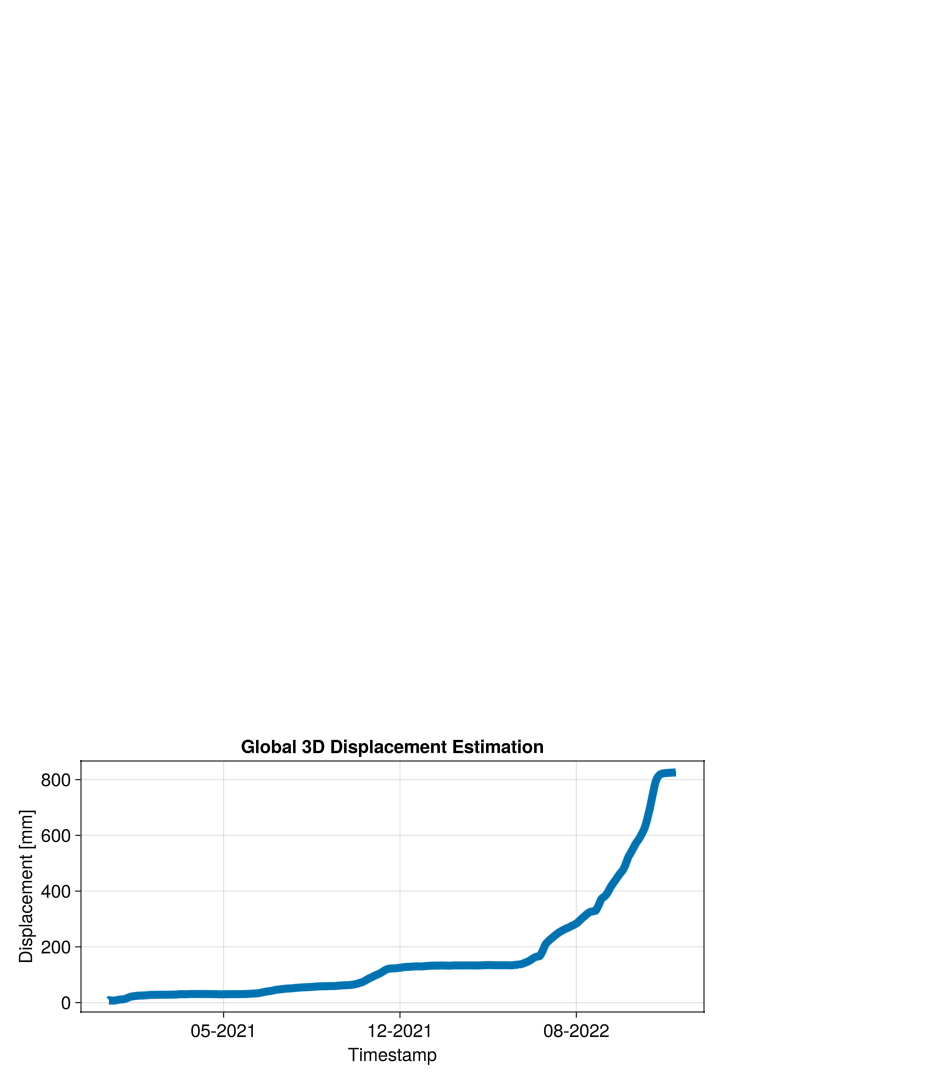

In [188]:
# Plot estimation results displacement
Makie.inline!(true)
fig_res = Figure(; size=(720, 0.5*720), fontsize=18)

offset = 12

x_label = "Timestamp"
y_label = "Displacement [mm]"
x =  datetime2unix.(df_all.timestamp[10:end-offset])

ax = Axis(fig_res[1, 1], title="Global 3D Displacement Estimation", xlabel=x_label, ylabel=y_label)
# ax_2 = Axis(fig_res[1, 1], ylabel="Velocity [mm/h]", yaxisposition=:right)
# hidexdecorations!(ax_2)
# hidespines!(ax_2)
displ_line = lines!(ax, x, global_displ_KF[1:end-offset], linewidth=8, label="Displacement")

ax.xtickformat = x -> Dates.format.(unix2datetime.(x), "mm-yyyy")

fig_res

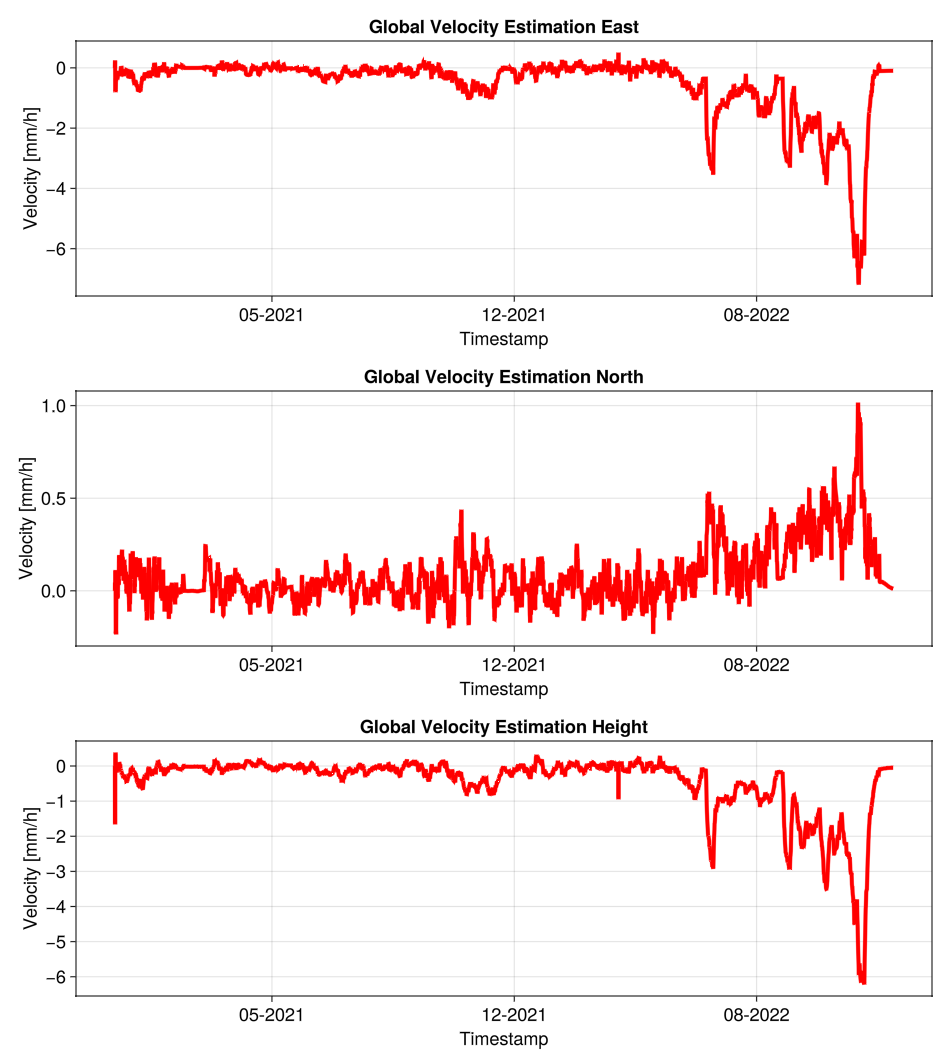

In [189]:
# Plot estimation results velocity
Makie.inline!(true)
fig_res = Figure(; size=(720, 1.5*720), fontsize=18)

offset = 12

x_label = "Timestamp"
y_label ="Velocity [mm/h]"
x =  datetime2unix.(df_all.timestamp[10:end-offset])

ax = Axis(fig_res[1, 1], title="Global Velocity Estimation East", xlabel=x_label, ylabel=y_label)
lines!(ax, x, gobal_speed_east_KF[1:end-offset], linewidth=4, color=:red, label="Velocity")

ax2 = Axis(fig_res[2, 1], title="Global Velocity Estimation North", xlabel=x_label, ylabel=y_label)
lines!(ax2, x, gobal_speed_north_KF[1:end-offset], linewidth=4, color=:red, label="Velocity")

ax3 = Axis(fig_res[3, 1], title="Global Velocity Estimation Height", xlabel=x_label, ylabel=y_label)
lines!(ax3, x, gobal_speed_height_KF[1:end-offset], linewidth=4, color=:red, label="Velocity")

ax.xtickformat = x -> Dates.format.(unix2datetime.(x), "mm-yyyy")
ax2.xtickformat = x -> Dates.format.(unix2datetime.(x), "mm-yyyy")
ax3.xtickformat = x -> Dates.format.(unix2datetime.(x), "mm-yyyy")

# Legend(fig_res[4,1], [displ_line, vel_line], ["Velocity"], orientation=:horizontal, tellwidth=false,tellheight=true)

fig_res

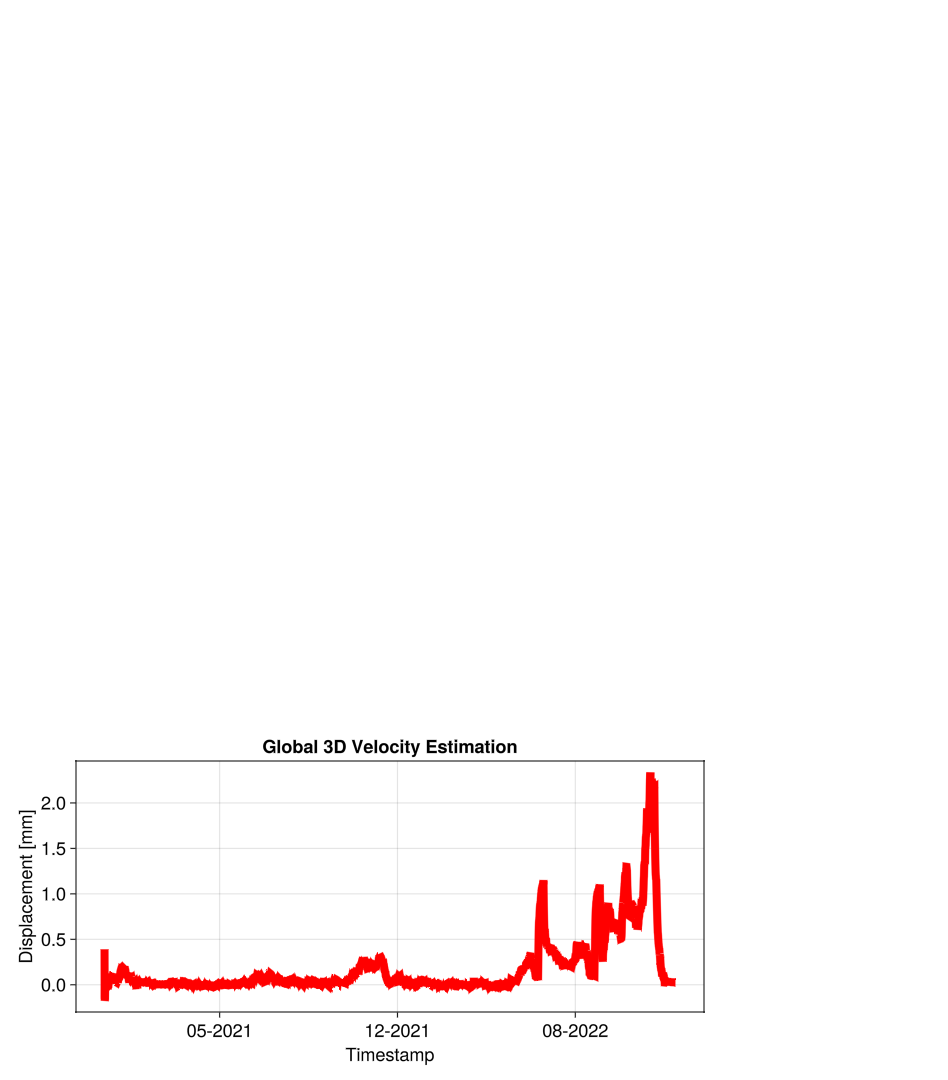

In [190]:
# Plot estimation results displacement
Makie.inline!(true)
fig_res = Figure(; size=(720, 0.5*720), fontsize=18)

offset = 12

x_label = "Timestamp"
y_label = "Displacement [mm]"
x =  datetime2unix.(df_all.timestamp[11:end-offset])

ax = Axis(fig_res[1, 1], title="Global 3D Velocity Estimation", xlabel=x_label, ylabel=y_label)
# ax_2 = Axis(fig_res[1, 1], ylabel="Velocity [mm/h]", yaxisposition=:right)
# hidexdecorations!(ax_2)
# hidespines!(ax_2)
displ_line = lines!(ax, x, diff(global_displ_KF[1:end-offset]), linewidth=8, label="Displacement", color=:red)

ax.xtickformat = x -> Dates.format.(unix2datetime.(x), "mm-yyyy")

fig_res

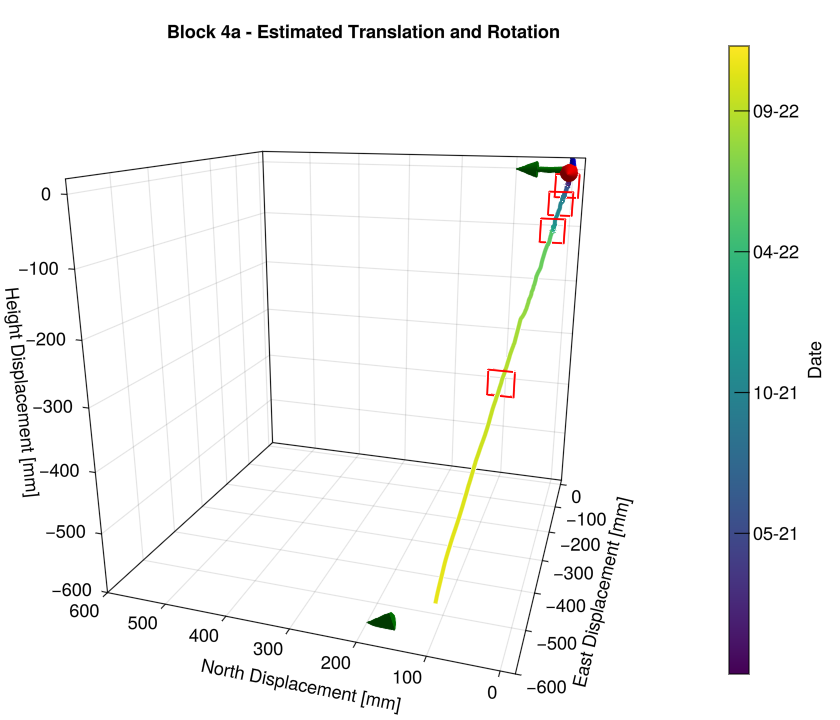

In [93]:
# 3D Plot
GLMakie.activate!()
Makie.inline!(true);

# Define the two vectors that indicate the orientation of the surface (replace with your own vectors)
# Use mean values over 200 normal vectors to withstand the influence of apparent noise
v1 = mean(cumulated_diffs_ts_df[1:400, "Orientation"])
v2 = mean(cumulated_diffs_ts_df[end-400:end, "Orientation"])

# Compute the rotation matrix that rotates from v1 to v2
q = rotation_between(v1, v2)

# Compute the rotation matrix
aa = AngleAxis(q)
R = RotMatrix(aa)

# Define the rotation matrix and initial vectors
v1 = [-100, 0, 0]  # Initial x-axis vector (inverted x-axis)
v2 = [0, 100, 0]  # Initial y-axis vector
v3 = [0, 0, 100]  # Initial z-axis vector

# Apply the rotation matrix to the initial vectors
v1_new = R * v1
v2_new = R * v2
v3_new = R * v3

n = size(df_all.timestamp[10:end-offset], 1)

arrow_size = Vec3f(20, 20, 50)

startpoint = Point3f(0, 0, 0)
endpoint = Point3f(global_east_KF[end-offset], global_north_KF[end-offset], global_height_KF[end-offset])

for i in 1:50

    v1_new = R * v1_new
    v2_new = R * v2_new
    v3_new = R * v3_new

end

f = Figure(size=(840, 720), fontsize=18)
ax = Axis3(
    f[1, 1],
    title="Block 4a - Estimated Translation and Rotation",
    xlabel="East Displacement [mm]",
    ylabel="North Displacement [mm]",
    zlabel="Height Displacement [mm]",
    aspect=(1, 1, 1),
    perspectiveness=0.5,
    # ticks=false,
    azimuth=1.1*pi,
    viewmode=:fitzoom,
    elevation=0.3,
    xlabeloffset=54,
    ylabeloffset=42,
    zlabeloffset=54,
)


hm = lines!(ax, global_east_KF[1:end-offset], global_north_KF[1:end-offset], global_height_KF[1:end-offset], color=1:n, linewidth=4)
ax2 = Colorbar(f[1, 2], hm; label="Date", vertical=true,
    flipaxis=true, ticksize=15, tickalign=1, width=20)
ax2.tickformat = x -> Dates.format.(df_all.timestamp[Int.(x)], "mm-yy")


# Plot coordinate systems to visualise orientation
arrows3d!([startpoint], [Vec3f(v1)], color=:red)
arrows3d!([startpoint], [Vec3f(v2)], color=:green)
arrows3d!([startpoint], [Vec3f(v3)], color=:blue)

arrows3d!([endpoint], [Vec3f(v1_new)], color=:red)
arrows3d!([endpoint], [Vec3f(v2_new)], color=:green)
arrows3d!([endpoint], [Vec3f(v3_new)], color=:blue)

wireframe!(ax, Rect3f(Point3f(global_east_KF[1000] - 2, global_north_KF[1000] - 20, global_height_KF[1000] - 20), Vec3f(2, 40, 40)), color=:red)
wireframe!(ax, Rect3f(Point3f(global_east_KF[2000] - 2, global_north_KF[2000] - 20, global_height_KF[2000] - 20), Vec3f(2, 40, 40)), color=:red)
wireframe!(ax, Rect3f(Point3f(global_east_KF[3000] - 2, global_north_KF[3000] - 20, global_height_KF[3000] - 20), Vec3f(2, 40, 40)), color=:red)
wireframe!(ax, Rect3f(Point3f(global_east_KF[4000] - 2, global_north_KF[4000] - 20, global_height_KF[4000] - 20), Vec3f(2, 40, 40)), color=:red)

# Set axis limits to have same scale
xlims!(ax, (-600, 20))
ylims!(ax, (-20, 600))
zlims!(ax, (-600, 20))

f

In [94]:
#Export results
df = DataFrame(
    timestamp = df_all.timestamp[10:end-offset],
    east = global_east_KF[1:end-offset],
    north = global_north_KF[1:end-offset],
    height = global_height_KF[1:end-offset]
)
# Write to CSV file
CSV.write("output/fusion-result-block4a-displacement.csv", df)

"output/fusion-result-block4a-displacement.csv"

## 4. Data Fusion for Base (lower part) with Global Kalman Filter



### 4.1 Local Filter for Total Station - Precompute

In [95]:
# build measurements based on df_t13_relative

base_measurements = df_t13_relative.Date
base_measurements = [base_measurements zeros(length(base_measurements)) zeros(length(base_measurements)) zeros(length(base_measurements))]

# Fill 2nd, 3rd and 4th column with senor type, description and measurements
for i in 1:size(base_measurements, 1)

    base_measurements[i,2] = "Total Station"
    base_measurements[i,3] = "t13"
    base_measurements[i,4] = [df_t13_relative.East[i] df_t13_relative.North[i] df_t13_relative.Height[i]]
    
end

In [96]:
# Filter for Total Station
include("asynchronous_kalman_filter.jl")

x0 = [0.; 0.; 0.]
P0 = diagm([1.,1.,1.])
A = diagm([1., 1., 1.])
Q = diagm([1., 1., 1.])
H = [1. 0 0; 0 1. 0; 0 0 1.]
R = [10. 0 0; 0 10. 0; 0 0 10.]

tracking = Tracking(
    x0,         # state vector
    P0,         # state covariance matrix
    A,          # state transition matrix
    Q,          # process covariance matrix
    H,          # Measurement matrix satellite
    R,          # Measurement covariance satellite
    zeros(3, 3) # Kalman filter gain
)

x_est = [[0., 0., 0.]]    # State vector
base_measurements_ts = []
sensors = ["Total Station"]

for i in 1:size(base_measurements,1)

    # Use function updating velocity
    timestamp = process_measurement(tracking, base_measurements[i,:], sensors)

    if (timestamp != nothing)
        push!(base_measurements_ts, timestamp)
        push!(x_est, tracking.kf.x)
    end

end

# Decompose state vector into seperate vectors
local_base_ts_east = [x_est[i][1] for i in 2:length(x_est)];
local_base_ts_north = [x_est[i][2] for i in 2:length(x_est)];
local_base_ts_height = [x_est[i][3] for i in 2:length(x_est)];

Kalman Filter Initialization


Export result

In [103]:
# Total Station
df = DataFrame(
    timestamp = base_measurements_ts,
    easting = local_base_ts_height,
    northing = local_base_ts_north,
    height = local_base_ts_height
)
# Write to CSV file
CSV.write("output/local_base_ts.csv", df)

"output/local_base_ts.csv"

### 4.2 Local Filter GB-InSAR - Precompute

In [98]:
# Define heading and incidence angle
heading_insar = deg2rad(184)
incidence_insar = deg2rad(90-22)
ns_comp = -cos(heading_insar) * sin(incidence_insar)
h_comp = cos(incidence_insar)

gb_d_ns = zeros(size(gb_df, 1))
gb_d_vert = zeros(size(gb_df, 1))

for i in 1:size(gb_df, 1)
    gb_d_ns[i] = (-gb_df[i, "Pts_03"] * ns_comp) / (ns_comp*h_comp)
    gb_d_vert[i] = (gb_df[i, "Pts_03"] * h_comp)
end


In [99]:
# Create measurements vector for gb-insar DataFrame
measurements_gb = gb_df.Date
measurements_gb = [measurements_gb zeros(length(measurements_gb)) zeros(length(measurements_gb)) zeros(length(measurements_gb))]

# Fill 2nd, 3rd and 4th column with senor type, description and measurements
for i in 1:size(measurements_gb, 1)

    measurements_gb[i,2] = "GB-INSAR"
    measurements_gb[i,3] = "Pts_03"
    measurements_gb[i,4] = [gb_d_ns[i] gb_d_vert[i]]
    
end

In [100]:
# Filter for ground-based InSAR
include("asynchronous_kalman_filter.jl")

x0 = [0.; 0.; 0.]
P0 = diagm([1.,1.,1.])
A = diagm([1., 1., 1.])
Q = diagm([1., 1., 1.])
H = [1. 0 0; 0 1. 0; 0 0 1.]
R = [10. 0 0; 0 10. 0; 0 0 10.]

tracking = Tracking(
    x0,         # state vector
    P0,         # state covariance matrix
    A,          # state transition matrix
    Q,          # process covariance matrix
    H,          # Measurement matrix satellite
    R,          # Measurement covariance satellite
    zeros(3, 3) # Kalman filter gain
)

x_est = [[0., 0., 0.]]    # State vector
timestamps_gb = []
sensors = ["GB-INSAR"]

for i in 1:size(measurements_gb,1)

    # Use function updating velocity
    timestamp = process_measurement(tracking, measurements_gb[i,:], sensors)

    if (timestamp != nothing)
        push!(timestamps_gb, timestamp)
        push!(x_est, tracking.kf.x)
    end

end

# Decompose state vector into seperate vectors
local_gb_east = [x_est[i][1] for i in 2:length(x_est)];
local_gb_north = [x_est[i][2] for i in 2:length(x_est)];
local_gb_height = [x_est[i][3] for i in 2:length(x_est)];

Kalman Filter Initialization


Export result

In [101]:
# Export ground-based InSAR
df = DataFrame(
    timestamp = timestamps_gb,
    northing = local_gb_north,
    height = local_gb_height
)
# Write to CSV file
CSV.write("output/local_base_gb.csv", df)

"output/local_base_gb.csv"

### 4.3 Resample to create input for Global Filter

While the local filters update the estimate asynchronously, the global filter acts as a syncrhonous aggregator. The outputs of the local filters are resampled and smoothened with a rolling window before used as input to the global filter.



Due to Julia not having a built-in resampling function, the resampling and filtering is done in a python notebook ([resampling_python.ipynb](resampling_python.ipynb))

Run the cells for the Base data in the python notebook and continue below. Intermediate results stored as CSV files are used to pass the data between the two notebooks.

### 4.4 Global Fusion with Synchronous Kalman Filter

In [104]:
function parse_date(date_str::AbstractString)
    return DateTime(date_str, "yyyy-mm-dd HH:MM:SS")
end

parse_date (generic function with 1 method)

Read data from resampling.

In [105]:
# Import data from output folder
df_all = CSV.read("output/local_all_filtered_base.csv", DataFrame)

# Convert String timestamps to datetime in timestamp Column
df_all.timestamp = map(parse_date, df_all.timestamp);

Define the global filter

In [106]:
# Filter for extensometer
include("asynchronous_kalman_filter.jl")

x0_global = [0.0; 0.0; 0.0]
P0_global = diagm([1.0, 1.0, 1.0])
A_global = diagm([1.0, 1.0, 1.0])
Q_global = diagm([10.0, 10.0, 10.0])

H_global_all = [1.0 0 0 #ts_east
    0 1.0 0     #ts_north
    0 0 1.0     #ts_height 
    0 1.0 0     #gb_north
    0 0 1.0     #gb_height
]

H_global_gb = [
    0 1.0 0     #gb_north
    0 0 1.0     #gb_height
]

R_global_all = diagm([1.0^2, 1.0^2, 1.0^2, 2.0867^2, 4.3622^2])
R_global_gb = diagm([2.0867^2, 4.3622^2])

global_est_KF = [[0.0, 0.0, 0.0]]    # State vector
global_K = [zeros(3, 3)]         # Kalman gain

x = x0_global
P = P0_global
K = zeros(3, 3)

for i in 10:size(df_all, 1)

    # Predict
    x = A_global * x
    P = A_global * P * A_global' + Q_global


    if ismissing(df_all[i, "ts_east"]) 
        H_global = H_global_gb
        R_global = R_global_gb
        z = [
            df_all[i, "gb_north"]
            df_all[i, "gb_height"]
        ]
    else
        H_global = H_global_all
        R_global = R_global_all
        z = [
            df_all[i, "ts_east"]
            df_all[i, "ts_north"]
            df_all[i, "ts_height"]
            df_all[i, "gb_north"]
            df_all[i, "gb_height"]
        ]
    end

    # update
    z_pred = H_global * x
    y = z - z_pred
    Ht = H_global'
    S = H_global * P * Ht + R_global
    K = P * Ht * inv(S)
    x = x + K * y
    P = (I - K * H_global) * P

    push!(global_est_KF, x)
    push!(global_K, K)

end

# Decompose state vector into seperate vectors
global_east_KF_base = [global_est_KF[i][1] for i in 2:length(global_est_KF)];
global_north_KF_base = [global_est_KF[i][2] for i in 2:length(global_est_KF)];
global_height_KF_base = [global_est_KF[i][3] for i in 2:length(global_est_KF)];

In [107]:
# Compute speeds
gobal_speed_east_KF_base = [0;diff(global_east_KF_base[1:end]).*4]
gobal_speed_north_KF_base = [0;diff(global_north_KF_base[1:end]).*4]
gobal_speed_height_KF_base = [0;diff(global_height_KF_base[1:end]).*4]

# Find values with speeds above 10 mm/h and filter them (set to 0)
gobal_speed_east_KF_base[gobal_speed_east_KF_base .> 10] .= 0
gobal_speed_north_KF_base[gobal_speed_north_KF_base .> 10] .= 0
gobal_speed_height_KF_base[abs.(gobal_speed_height_KF_base) .> 10] .= 0
# gobal_speed_height[gobal_speed_height .< 10] .= 0|

6-element view(::Vector{Float64}, [4381, 4382, 4383, 4384, 4385, 4386]) with eltype Float64:
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0

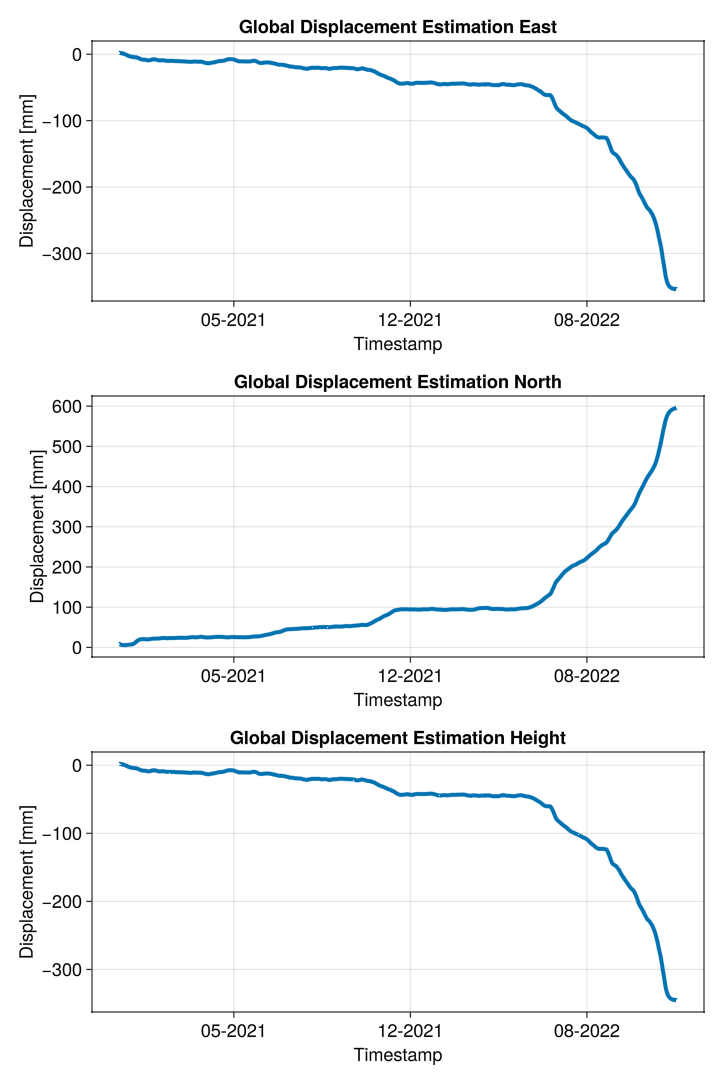

In [108]:
# Plot estimation results
Makie.inline!(true)
fig_res = Figure(; size=(720, 1.5*720), fontsize=18)

offset = 90

x_label = "Timestamp"
y_label = "Displacement [mm]"
x =  datetime2unix.(df_all.timestamp[10:end-offset])

ax = Axis(fig_res[1, 1], title="Global Displacement Estimation East", xlabel=x_label, ylabel=y_label)
# ax_2 = Axis(fig_res[1, 1], ylabel="Velocity [mm/h]", yaxisposition=:right)
# hidexdecorations!(ax_2)
# hidespines!(ax_2)
displ_line = lines!(ax, x, global_east_KF_base[1:end-offset], linewidth=4, label="Displacement")
# vel_line = lines!(ax_2, x, gobal_speed_east_KF_base[1:end-offset], linewidth=4, color=:red, label="Velocity")

ax2 = Axis(fig_res[2, 1], title="Global Displacement Estimation North", xlabel=x_label, ylabel=y_label)
# ax2_2 = Axis(fig_res[2, 1], ylabel="Velocity [mm/h]", yaxisposition=:right)
# hidexdecorations!(ax2_2)
# hidespines!(ax2_2)
lines!(ax2, x, global_north_KF_base[1:end-offset], linewidth=4, label="Displacement")
# lines!(ax2_2, x, gobal_speed_north_KF_base[1:end-offset], linewidth=4, color=:red, label="Velocity")

ax3 = Axis(fig_res[3, 1], title="Global Displacement Estimation Height", xlabel=x_label, ylabel=y_label)
# ax3_2 = Axis(fig_res[3, 1], ylabel="Velocity [mm/h]", yaxisposition=:right)
# hidexdecorations!(ax3_2)
# hidespines!(ax3_2)
lines!(ax3, x, global_height_KF_base[1:end-offset], linewidth=4, label="Displacement")
# lines!(ax3_2, x, gobal_speed_height_KF_base[1:end-offset], linewidth=4, color=:red, label="Velocity")

ax.xtickformat = x -> Dates.format.(unix2datetime.(x), "mm-yyyy")
ax2.xtickformat = x -> Dates.format.(unix2datetime.(x), "mm-yyyy")
ax3.xtickformat = x -> Dates.format.(unix2datetime.(x), "mm-yyyy")

# Legend(fig_res[4,1], [displ_line, vel_line], ["Displacement", "Velocity"], orientation=:horizontal, tellwidth=false,tellheight=true)

fig_res

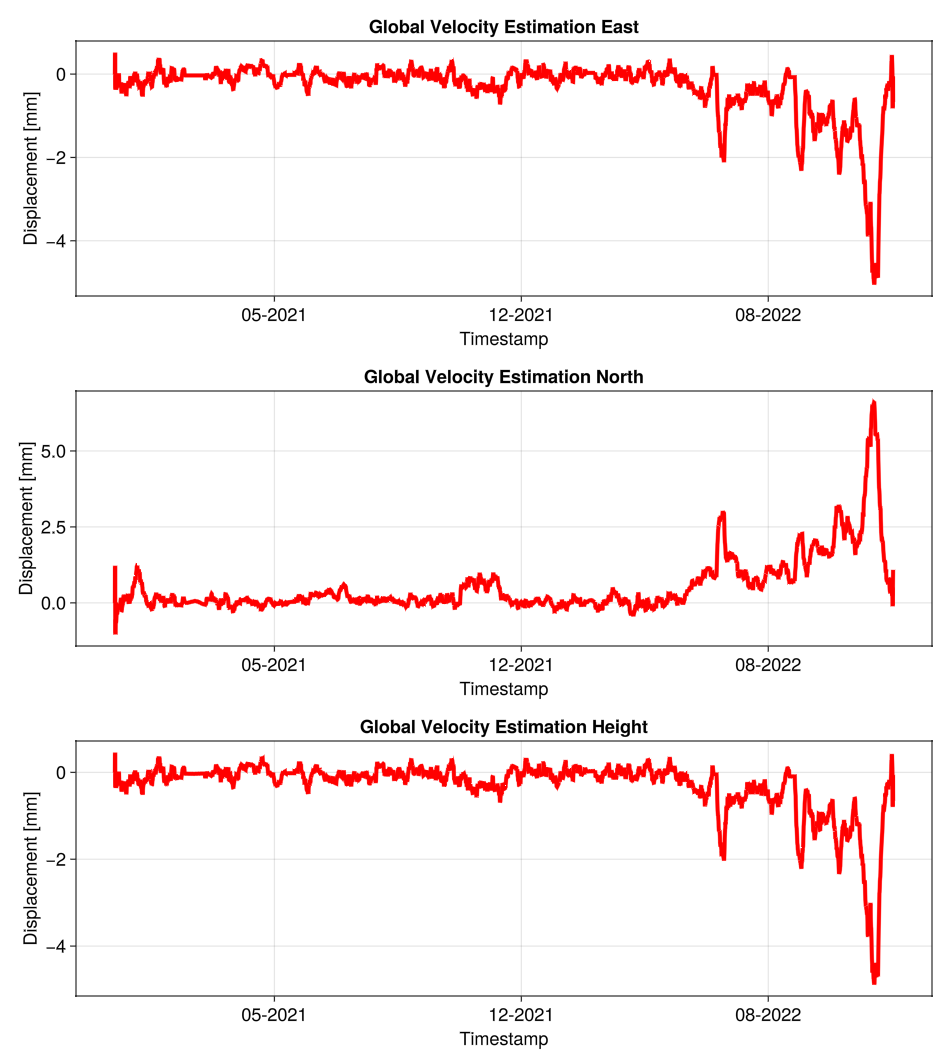

In [109]:
# Plot estimation results for velocity
Makie.inline!(true)
fig_res = Figure(; size=(720, 1.5*720), fontsize=18)

offset = 90

x_label = "Timestamp"
y_label = "Displacement [mm]"
x =  datetime2unix.(df_all.timestamp[10:end-offset])

ax = Axis(fig_res[1, 1], title="Global Velocity Estimation East", xlabel=x_label, ylabel=y_label)
vel_line = lines!(ax, x, gobal_speed_east_KF_base[1:end-offset], linewidth=4, color=:red, label="Velocity")

ax2 = Axis(fig_res[2, 1], title="Global Velocity Estimation North", xlabel=x_label, ylabel=y_label)
lines!(ax2, x, gobal_speed_north_KF_base[1:end-offset], linewidth=4, color=:red, label="Velocity")

ax3 = Axis(fig_res[3, 1], title="Global Velocity Estimation Height", xlabel=x_label, ylabel=y_label)
lines!(ax3, x, gobal_speed_height_KF_base[1:end-offset], linewidth=4, color=:red, label="Velocity")

ax.xtickformat = x -> Dates.format.(unix2datetime.(x), "mm-yyyy")
ax2.xtickformat = x -> Dates.format.(unix2datetime.(x), "mm-yyyy")
ax3.xtickformat = x -> Dates.format.(unix2datetime.(x), "mm-yyyy")

# Legend(fig_res[4,1], [displ_line, vel_line], ["Displacement", "Velocity"], orientation=:horizontal, tellwidth=false,tellheight=true)

fig_res

In [111]:
# Compute 3D displacement
global_displ_KF_base = [sqrt(global_east_KF_base[i]^2 + global_north_KF_base[i]^2 + global_height_KF_base[i]^2) for i in 1:length(global_east_KF_base)];

## 5. Combined Analysis

Inspect the estiatmes for Block4a and Base together.

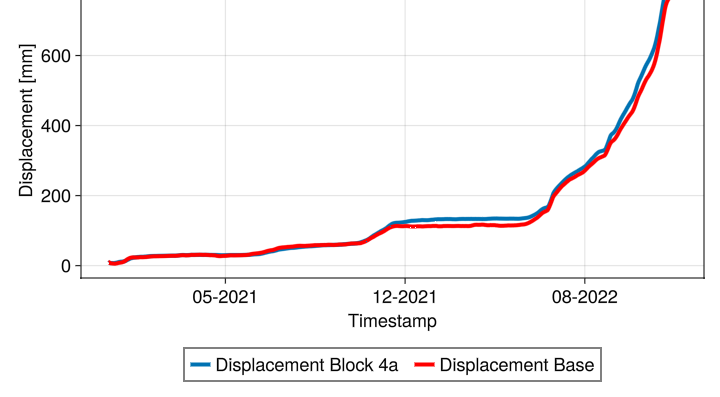

In [115]:
# plot 3d displacement with global_east_KF, global_north_KF, global_height_KF

# Plot estimation results
Makie.inline!(true)
fig_res = Figure(; size=(720, 0.66*720), fontsize=18)

offset = 90

x_label = "Timestamp"
y_label = "Displacement [mm]"
x =  datetime2unix.(df_all.timestamp[10:end-offset])

ax = Axis(fig_res[1, 1], title="Estimated 3D Displacement", xlabel=x_label, ylabel=y_label)
displ_line = lines!(ax, x, global_displ_KF[1:end-(offset+5)], linewidth=4, label="Block 4a")
displ_baseline = lines!(ax, x, global_displ_KF_base[1:end-(offset)], linewidth=4, label="Base", color=:red)

ax.xtickformat = x -> Dates.format.(unix2datetime.(x), "mm-yyyy")

Legend(fig_res[2,1], [displ_line, displ_baseline], ["Displacement Block 4a", "Displacement Base"], orientation=:horizontal, tellwidth=false,tellheight=true)

fig_res